# Hotel Booking Cancellation Prediction Using Machine Learning

## IT3051 – Fundamentals of Data Mining
### Progress Evaluation 1

**Dataset:** Hotel Booking Dataset  
**Target Variable:** `is_canceled`  
**Data Mining Task:** Supervised Binary Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = 'hotel_bookings.csv'

df = pd.read_csv(file_path)

In [3]:
print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 119390
Number of columns: 32


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


## 1. Dataset Understanding

This section examines the basic structure and characteristics of the Hotel Booking dataset before performing data cleaning, preprocessing, or exploratory data analysis.

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 119390
Number of columns: 32


In [8]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Initial Observations

The dataset contains 119,390 booking records and 32 variables with a mixture of numerical and categorical data types. Initial inspection indicates that some variables contain missing values, particularly `children`, `country`, `agent`, and `company`. These issues will be investigated in detail during the data-quality analysis before making any preprocessing decisions.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


### Observations from Descriptive Statistics

The numerical summary provides an initial view of the distributions and ranges of the numerical variables. The target variable `is_canceled` has a mean of approximately 0.37, suggesting that cancellations represent a substantial proportion of the dataset. The exact class distribution will be examined separately.

Several variables contain values that require further investigation. For example, `lead_time` reaches 737 days, `adults` reaches 55, `stays_in_week_nights` reaches 50, and `days_in_waiting_list` reaches 391. These values are not assumed to be errors at this stage, but their distributions should be investigated during EDA.

The `adr` variable ranges from -6.38 to 5400, compared with a median of approximately 94.58. This suggests the presence of unusual or extreme values that require further investigation.

The `agent` and `company` variables represent identifiers/codes rather than continuous numerical measurements. Therefore, numerical summary statistics such as their mean and standard deviation should be interpreted cautiously.

No records or variables are modified at this stage. These observations will be used to guide the later data-quality, outlier, and preprocessing analysis.

In [11]:
# Identify columns based on their current pandas data types
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print(numerical_columns)

print("\nNumber of object/categorical columns:", len(categorical_columns))
print(categorical_columns)

Number of numerical columns: 20
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Number of object/categorical columns: 12
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\DELL\AppData\Local\Temp\ipykernel_22556\3912574992.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


### Initial Variable Type Analysis

Based on the pandas data types, the dataset contains 20 numerical-type columns and 12 object-type columns. However, the technical data type does not always represent the actual meaning of a variable.

For example, `agent` and `company` are stored as numerical values but represent identifiers/codes rather than continuous numerical measurements. The variable `is_repeated_guest` is stored as an integer but represents a binary indicator. Similarly, `reservation_status_date` is currently stored as an object even though it represents date information.

Therefore, variables will be interpreted according to both their stored data type and their actual meaning before preprocessing decisions are made.

In [12]:
# Count the number of unique values in each column
unique_counts = df.nunique().sort_values()

print("Number of unique values in each column:")
print(unique_counts)

Number of unique values in each column:
hotel                                2
is_canceled                          2
is_repeated_guest                    2
arrival_date_year                    3
deposit_type                         3
reservation_status                   3
customer_type                        4
babies                               5
meal                                 5
distribution_channel                 5
children                             5
required_car_parking_spaces          5
total_of_special_requests            6
market_segment                       8
reserved_room_type                  10
arrival_date_month                  12
assigned_room_type                  12
adults                              14
previous_cancellations              15
stays_in_weekend_nights             17
booking_changes                     21
arrival_date_day_of_month           31
stays_in_week_nights                35
arrival_date_week_number            53
previous_bookings_not_ca

### Observations from Unique-Value Analysis

The unique-value analysis shows that the dataset contains variables with different levels of cardinality. Variables such as `hotel`, `is_canceled`, and `is_repeated_guest` have only two unique values, while variables such as `meal`, `customer_type`, `market_segment`, and room-type variables contain a relatively small number of categories.

The `country`, `agent`, and `company` variables have relatively high cardinality. In particular, `agent` and `company` represent codes/identifiers, so their treatment will require further consideration during preprocessing.

The `adr` variable has a large number of unique numerical values, which is consistent with a continuous numerical variable. The `reservation_status_date` variable also contains many unique values and represents date information. Its suitability as a predictor will be investigated later, particularly with respect to potential data leakage.

No variables are removed or transformed at this stage.

## 2. Target Variable Analysis

The target variable for this project is `is_canceled`, where:

- `0` = Booking was not cancelled
- `1` = Booking was cancelled

The distribution of the target variable is examined to understand the proportion of cancelled and non-cancelled bookings and to identify whether class imbalance is present.

In [13]:
# Count each target class
target_counts = df['is_canceled'].value_counts().sort_index()

# Calculate percentage of each class
target_percentages = df['is_canceled'].value_counts(normalize=True).sort_index() * 100

print("Target Class Counts:")
print(target_counts)

print("\nTarget Class Percentages:")
print(target_percentages.round(2))

Target Class Counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target Class Percentages:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


### Target Distribution Observations

The target variable `is_canceled` contains two classes:

- **Not Cancelled (0):** 75,166 bookings (62.96%)
- **Cancelled (1):** 44,224 bookings (37.04%)

The dataset therefore contains more non-cancelled bookings than cancelled bookings. Although the class distribution is unequal, the minority class still represents 37.04% of the dataset, so the imbalance is not considered extreme.

This class distribution will be considered during model evaluation. In addition to accuracy, appropriate classification metrics such as precision, recall, F1-score, and the confusion matrix can later be considered when evaluating the machine-learning models.

No class-balancing technique is applied at this stage.

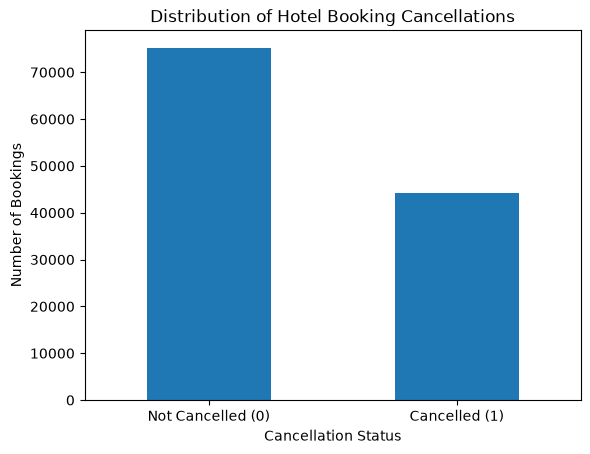

In [14]:
# Visualize the target class distribution
target_counts.plot(kind='bar')

plt.title('Distribution of Hotel Booking Cancellations')
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Bookings')
plt.xticks([0, 1], ['Not Cancelled (0)', 'Cancelled (1)'], rotation=0)
plt.show()

### Interpretation

The visualization confirms that non-cancelled bookings form the majority class in the dataset. However, cancelled bookings also represent a substantial proportion of the observations. Therefore, the target variable shows a moderate difference in class frequencies rather than a severe imbalance.

## 3. Data Quality Analysis

### 3.1 Missing Values

Missing values are examined before preprocessing to identify incomplete variables and determine the extent of missing data. Both the number and percentage of missing values are calculated. No missing values are treated at this stage; appropriate handling methods will be selected later based on the characteristics and meaning of each variable.

In [15]:
# Calculate missing-value count and percentage for each column
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage.round(2)
})

# Display only columns containing missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Sort from highest to lowest missing percentage
missing_summary = missing_summary.sort_values(
    by='Missing Percentage (%)',
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


### Missing-Value Observations

Missing values are present in four variables: `company`, `agent`, `country`, and `children`.

- `company` contains 112,593 missing values (94.31%), indicating extremely high missingness. Because most observations do not contain a company value, the usefulness of this variable and its appropriate treatment require careful consideration.
- `agent` contains 16,340 missing values (13.69%). Since this variable represents an agent identifier/code, the meaning of a missing value should be considered before selecting a treatment method.
- `country` contains 488 missing values (0.41%), representing only a small proportion of the dataset.
- `children` contains only 4 missing values (approximately 0.003% of the dataset).

At this stage, no missing values are removed or imputed. The appropriate treatment for each variable will be determined during preprocessing based on the variable meaning, amount of missingness, and potential usefulness for prediction.

### 3.2 Duplicate Records

Duplicate records are examined to determine whether identical booking observations occur in the dataset. Identifying duplicates is important because unnecessary repeated records may influence the analysis and machine-learning models.

In [16]:
# Count fully duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:",
      round((duplicate_count / len(df)) * 100, 2), "%")

Number of duplicate rows: 31994
Percentage of duplicate rows: 26.8 %


### Duplicate-Record Observations

The dataset contains 31,994 rows (26.80%) that are identified as exact duplicates of earlier rows.

This is a substantial proportion of the dataset and therefore requires further investigation. The duplicate count produced by `df.duplicated()` represents repeated occurrences after the first occurrence of an identical record.

Duplicate records are not removed at this stage. They will first be inspected to determine whether they represent unnecessary repeated records and whether their removal is justified during preprocessing.

In [17]:
# Display examples of records involved in duplication
duplicate_records = df[df.duplicated(keep=False)]

print("Total rows involved in duplicate groups:", len(duplicate_records))

duplicate_records.sort_values(
    by=list(df.columns)
).head(10)

Total rows involved in duplicate groups: 40165


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
76793,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
76794,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
41067,City Hotel,0,0,2015,August,33,11,0,1,1,...,No Deposit,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41073,City Hotel,0,0,2015,August,33,11,0,1,1,...,No Deposit,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41071,City Hotel,0,0,2015,August,33,11,0,1,2,...,No Deposit,NaN,NaN,0,Transient,80.0,0,0,Check-Out,2015-08-12


### Duplicate Investigation

A total of 31,994 records (26.80%) are identified as duplicate occurrences using all 32 variables. When all members of duplicate groups are included using `keep=False`, 40,165 records are involved in duplicate groups.

Inspection of example duplicate groups shows records with identical values across all available variables. However, the dataset does not contain a unique booking identifier that could definitively distinguish separate bookings with otherwise identical characteristics.

Therefore, duplicate records are treated as a significant data-quality issue requiring a justified preprocessing decision. No duplicate records are removed during the current investigation stage.

In [18]:
# Identify bookings with no recorded guests
zero_guest_records = df[
    (df['adults'] == 0) &
    (df['children'].fillna(0) == 0) &
    (df['babies'] == 0)
]

print("Number of bookings with zero total guests:", len(zero_guest_records))
print("Percentage of dataset:",
      round((len(zero_guest_records) / len(df)) * 100, 2), "%")

zero_guest_records.head()

Number of bookings with zero total guests: 180
Percentage of dataset: 0.15 %


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


### Zero-Guest Booking Observation

A total of 180 records (0.15% of the dataset) contain zero recorded guests, where `adults`, `children`, and `babies` are all zero.

These records are unusual because a hotel booking would normally be expected to contain at least one guest. However, they are not automatically removed at this stage because the available data does not confirm why these records exist.

They are therefore identified as potentially invalid or unusual observations and will be considered during the preprocessing stage.

In [19]:
# Examine minimum and maximum values of selected numerical variables
columns_to_check = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

range_summary = pd.DataFrame({
    'Minimum': df[columns_to_check].min(),
    'Maximum': df[columns_to_check].max()
})

range_summary

,Minimum,Maximum
lead_time,0.00,737.0
stays_in_weekend_nights,0.00,19.0
stays_in_week_nights,0.00,50.0
adults,0.00,55.0
children,0.00,10.0
babies,0.00,10.0
previous_cancellations,0.00,26.0
previous_bookings_not_canceled,0.00,72.0
booking_changes,0.00,21.0
days_in_waiting_list,0.00,391.0


### Initial Numerical Range Observations

The range analysis identifies several numerical variables with potentially unusual or extreme values.

The `adr` (Average Daily Rate) variable ranges from -6.38 to 5400. A negative room rate is unusual, while the maximum value is substantially higher than the typical values observed in the descriptive statistics. Therefore, `adr` requires further outlier investigation.

Other variables also contain large maximum values, including `lead_time` (737 days), `adults` (55), `children` (10), `babies` (10), `stays_in_week_nights` (50), and `days_in_waiting_list` (391). These values are not automatically considered errors because they may represent valid but rare observations.

Further distribution and outlier analysis is required before deciding whether any observations should be treated or removed.

In [20]:
# Calculate IQR boundaries for ADR
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

adr_outliers = df[
    (df['adr'] < lower_bound) |
    (df['adr'] > upper_bound)
]

print("ADR Q1:", Q1)
print("ADR Q3:", Q3)
print("ADR IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of potential ADR outliers:", len(adr_outliers))
print(
    "Percentage of potential ADR outliers:",
    round(len(adr_outliers) / len(df) * 100, 2),
    "%"
)

ADR Q1: 69.29
ADR Q3: 126.0
ADR IQR: 56.709999999999994
Lower bound: -15.774999999999991
Upper bound: 211.065
Number of potential ADR outliers: 3793
Percentage of potential ADR outliers: 3.18 %


### ADR Outlier Investigation

Using the IQR method, the first quartile (Q1) of `adr` is 69.29 and the third quartile (Q3) is 126.00, producing an IQR of 56.71. Based on the 1.5 × IQR rule, values below approximately -15.78 or above approximately 211.07 are identified as potential statistical outliers.

A total of 3,793 records (3.18% of the dataset) fall outside these IQR boundaries. These observations are considered potential outliers rather than automatically invalid records.

The minimum `adr` value of -6.38 is not identified as an outlier by the IQR rule because it remains above the calculated lower boundary. However, a negative Average Daily Rate is semantically unusual and therefore requires separate consideration.

No ADR values are removed, capped, or transformed at this stage. Appropriate treatment will be determined during preprocessing after considering both statistical evidence and the meaning of the variable.

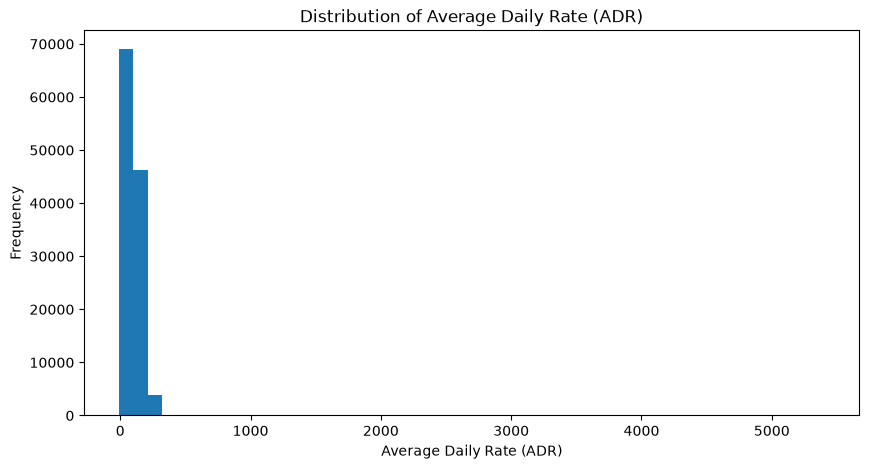

In [21]:
# Visualize the distribution of ADR
plt.figure(figsize=(10, 5))

plt.hist(df['adr'].dropna(), bins=50)

plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('Average Daily Rate (ADR)')
plt.ylabel('Frequency')

plt.show()

### ADR Distribution Observation

The histogram shows that most `adr` values are concentrated within a relatively low range, while a small number of extremely large values extend the distribution to approximately 5400.

These extreme observations cause the majority of the ADR distribution to appear compressed on the left side of the histogram. This supports the earlier IQR analysis, which identified a right-skewed distribution with potential high-value outliers.

The full dataset is retained at this stage. A restricted visualization will be used next to examine the main ADR distribution more clearly without removing or modifying any observations.

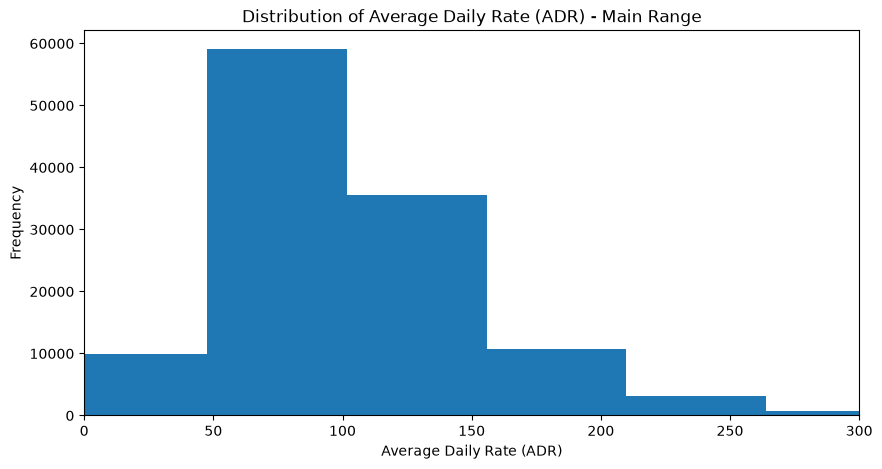

In [22]:
# Visualize the main ADR distribution more clearly
plt.figure(figsize=(10, 5))

plt.hist(df['adr'].dropna(), bins=100)

plt.xlim(0, 300)

plt.title('Distribution of Average Daily Rate (ADR) - Main Range')
plt.xlabel('Average Daily Rate (ADR)')
plt.ylabel('Frequency')

plt.show()

### Main ADR Distribution Observation

After restricting the displayed x-axis to the 0–300 range, the main distribution of `adr` becomes clearer. Most bookings have ADR values concentrated in the lower and middle part of this range, with the frequency generally decreasing as ADR increases.

Together with the full-range histogram and IQR analysis, this indicates that `adr` has a right-skewed distribution with a relatively small number of unusually high values.

The restricted x-axis is used only for visualization and does not remove or modify any observations in the dataset.

In [23]:
# Investigate unusually low and very high ADR values
print("Negative ADR records:", (df['adr'] < 0).sum())
print("ADR greater than 500:", (df['adr'] > 500).sum())
print("ADR greater than 1000:", (df['adr'] > 1000).sum())

# Display the highest ADR records
df.nlargest(10, 'adr')[
    ['hotel', 'is_canceled', 'adr', 'adults', 'children',
     'babies', 'stays_in_weekend_nights', 'stays_in_week_nights']
]

Negative ADR records: 1
ADR greater than 500: 3
ADR greater than 1000: 1


,hotel,is_canceled,adr,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights
48515,City Hotel,1,5400.00,2,0.0,0,0,1
111403,City Hotel,0,510.00,1,0.0,0,0,1
15083,Resort Hotel,0,508.00,2,0.0,0,0,1
103912,City Hotel,0,451.50,2,2.0,0,1,1
13142,Resort Hotel,1,450.00,2,0.0,0,4,10
13391,Resort Hotel,1,437.00,2,2.0,0,2,4
39155,Resort Hotel,0,426.25,2,2.0,0,2,6
39568,Resort Hotel,0,402.00,3,1.0,0,2,3
39118,Resort Hotel,0,397.38,3,2.0,0,3,5
13323,Resort Hotel,1,392.00,2,1.0,0,2,8


### Investigation of Extreme ADR Values

---



---



---



Further investigation shows that only 1 record has a negative `adr`, 3 records have an `adr` greater than 500, and only 1 record has an `adr` greater than 1000.

The maximum ADR value of 5400 is substantially higher than the remaining observations; the next-highest observed value is 510. This makes the 5400 value particularly unusual and potentially influential in later analysis and modelling.

The IQR method previously identified 3,793 potential ADR outliers. However, these results demonstrate that statistical outliers should not automatically be considered invalid records, since many may represent legitimate higher-priced bookings.

Therefore, no ADR observations are removed at this stage. The extreme and negative ADR observations will be considered separately when making preprocessing decisions.

In [24]:
# Investigate unusually large numbers of adults
print("Bookings with more than 10 adults:",
      (df['adults'] > 10).sum())

print("Bookings with more than 20 adults:",
      (df['adults'] > 20).sum())

# Display records with the highest numbers of adults
df.nlargest(10, 'adults')[
    ['hotel', 'is_canceled', 'adults', 'children', 'babies',
     'stays_in_weekend_nights', 'stays_in_week_nights',
     'adr', 'customer_type']
]

Bookings with more than 10 adults: 12
Bookings with more than 20 adults: 10


,hotel,is_canceled,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,adr,customer_type
2173,Resort Hotel,1,55,0.0,0,2,0,0.0,Group
1643,Resort Hotel,1,50,0.0,0,1,2,0.0,Group
1539,Resort Hotel,1,40,0.0,0,0,3,0.0,Group
1917,Resort Hotel,1,27,0.0,0,1,3,0.0,Group
1962,Resort Hotel,1,27,0.0,0,1,3,0.0,Group
1587,Resort Hotel,1,26,0.0,0,2,5,0.0,Group
1752,Resort Hotel,1,26,0.0,0,2,5,0.0,Group
1884,Resort Hotel,1,26,0.0,0,2,5,0.0,Group
2003,Resort Hotel,1,26,0.0,0,2,5,0.0,Group
2164,Resort Hotel,1,26,0.0,0,2,5,0.0,Group


### Investigation of Unusually Large Adult Counts

Only 12 bookings contain more than 10 adults, and 10 bookings contain more than 20 adults.

Inspection of the records with the highest adult counts shows that these observations are associated with the `Group` customer type. For example, the largest values include bookings for 55, 50, 40, 27, and 26 adults.

This contextual information suggests that the large adult counts may represent genuine group reservations rather than data-entry errors. Therefore, these observations should not be removed solely because they are statistically extreme.

No adult-count observations are modified or removed at this stage.

In [25]:
# Create total stay length for investigation only
total_stay = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

print("Bookings with zero total nights:",
      (total_stay == 0).sum())

print("Bookings longer than 30 nights:",
      (total_stay > 30).sum())

print("Maximum total stay:",
      total_stay.max())

Bookings with zero total nights: 715
Bookings longer than 30 nights: 24
Maximum total stay: 69


### Investigation of Stay Length

A total of 715 bookings have a recorded stay length of zero nights, while only 24 bookings have a total stay longer than 30 nights. The maximum recorded total stay is 69 nights.

The small number of very long stays suggests that these observations are rare and potentially extreme, but they may still represent legitimate long-duration bookings. Therefore, they are not automatically treated as errors.

The 715 zero-night records require further consideration because both weekend-night and weekday-night values are zero. These observations may represent special booking circumstances or unusual records, and their treatment should be justified before preprocessing.

No stay-length records are removed or modified at this stage.

In [26]:
# Investigate unusually large child and baby counts
print("Bookings with more than 5 children:",
      (df['children'] > 5).sum())

print("Bookings with more than 5 babies:",
      (df['babies'] > 5).sum())

df[
    (df['children'] > 5) |
    (df['babies'] > 5)
][
    ['hotel', 'is_canceled', 'adults', 'children',
     'babies', 'customer_type', 'adr']
]

Bookings with more than 5 children: 1
Bookings with more than 5 babies: 2


,hotel,is_canceled,adults,children,babies,customer_type,adr
328,Resort Hotel,1,2,10.0,0,Contract,133.16
46619,City Hotel,0,2,0.0,10,Transient,84.45
78656,City Hotel,0,1,0.0,9,Transient-Party,95.00


### Investigation of Unusual Child and Baby Counts

The investigation identified only one booking with more than five children and two bookings with more than five babies. The unusual observations include values of 10 children, 10 babies, and 9 babies.

These values are extremely rare within the dataset. However, the available variables do not provide sufficient evidence to determine whether they represent genuine bookings or data-entry errors.

Therefore, these observations are documented as unusual values rather than automatically removed. Any treatment of these records will be justified during preprocessing.

### 3.3 Potential Data Leakage Investigation

Potential data leakage is investigated to identify variables that may contain information about the final booking outcome. Since the objective is to predict cancellation before the outcome is known, variables that reveal information only available after cancellation or completion of the booking should not be used as predictors.

In [27]:
# Examine reservation status against the target variable
status_target_table = pd.crosstab(
    df['reservation_status'],
    df['is_canceled']
)

status_target_table

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


### Reservation Status Leakage

The cross-tabulation between `reservation_status` and the target variable `is_canceled` reveals a direct relationship between the two variables.

All 75,166 records with a `Check-Out` status belong to the non-cancelled class (`is_canceled = 0`). In contrast, all 43,017 records with a `Canceled` status and all 1,207 records with a `No-Show` status belong to the cancelled class (`is_canceled = 1`).

Therefore, `reservation_status` directly reveals the final booking outcome and represents a clear source of target leakage. Including this variable as a predictor would provide the machine-learning model with information that would not be available at the intended prediction time.

For this reason, `reservation_status` will be excluded from the predictor variables during preprocessing.

In [28]:
# Inspect reservation status date
print("Data type:",
      df['reservation_status_date'].dtype)

print("Number of unique dates:",
      df['reservation_status_date'].nunique())

print("\nEarliest dates:")
print(df['reservation_status_date'].sort_values().head())

print("\nLatest dates:")
print(df['reservation_status_date'].sort_values().tail())

Data type: str
Number of unique dates: 926

Earliest dates:
73829    2014-10-17
73809    2014-10-17
73810    2014-10-17
73811    2014-10-17
73812    2014-10-17
Name: reservation_status_date, dtype: str

Latest dates:
40054    2017-09-10
40053    2017-09-10
40057    2017-09-12
40058    2017-09-14
40059    2017-09-14
Name: reservation_status_date, dtype: str


In [29]:
# Compare reserved and assigned room types
same_room_type = (
    df['reserved_room_type'] == df['assigned_room_type']
).sum()

different_room_type = (
    df['reserved_room_type'] != df['assigned_room_type']
).sum()

print("Same reserved and assigned room type:", same_room_type)
print("Different reserved and assigned room type:", different_room_type)

print(
    "Percentage with different room type:",
    round((different_room_type / len(df)) * 100, 2),
    "%"
)

Same reserved and assigned room type: 104473
Different reserved and assigned room type: 14917
Percentage with different room type: 12.49 %


### Assigned Room Type Timing Consideration

The comparison shows that 104,473 bookings (87.51%) have the same reserved and assigned room type, while 14,917 bookings (12.49%) have a different assigned room type.

The `reserved_room_type` variable represents the room type originally requested during the booking process. In contrast, `assigned_room_type` represents the room type eventually assigned to the booking and may be determined or changed after the original reservation is made.

Therefore, although `assigned_room_type` does not directly reveal the cancellation outcome in the same way as `reservation_status`, its availability depends on the intended prediction time. Since this project aims to predict cancellation using information available at or near booking confirmation, `assigned_room_type` is considered a potential timing-related leakage risk.

Its exclusion from the final predictor set will therefore be considered during preprocessing.

In [30]:
# Investigate booking changes
print("Bookings with no changes:",
      (df['booking_changes'] == 0).sum())

print("Bookings with one or more changes:",
      (df['booking_changes'] > 0).sum())

print(
    "Percentage with one or more changes:",
    round((df['booking_changes'] > 0).mean() * 100, 2),
    "%"
)

print("Maximum number of booking changes:",
      df['booking_changes'].max())

Bookings with no changes: 101314
Bookings with one or more changes: 18076
Percentage with one or more changes: 15.14 %
Maximum number of booking changes: 21


### Booking Changes Timing Consideration

The analysis shows that 101,314 bookings have no recorded booking changes, while 18,076 bookings (15.14%) contain one or more changes. The maximum recorded number of booking changes is 21.

The `booking_changes` variable does not directly reveal whether a booking was cancelled. However, some booking changes may occur after the initial reservation has been created.

Since the intended prediction point for this project is at or near the time of booking confirmation, information about future booking changes may not yet be available. Therefore, `booking_changes` is considered a timing-sensitive variable and a potential source of leakage depending on when the prediction is made.

Its inclusion or exclusion will be determined during preprocessing according to the defined prediction point.

In [31]:
# Investigate days in waiting list
print("Bookings with zero waiting days:",
      (df['days_in_waiting_list'] == 0).sum())

print("Bookings with one or more waiting days:",
      (df['days_in_waiting_list'] > 0).sum())

print(
    "Percentage with one or more waiting days:",
    round((df['days_in_waiting_list'] > 0).mean() * 100, 2),
    "%"
)

print("Maximum days in waiting list:",
      df['days_in_waiting_list'].max())

Bookings with zero waiting days: 115692
Bookings with one or more waiting days: 3698
Percentage with one or more waiting days: 3.1 %
Maximum days in waiting list: 391


### Days in Waiting List Timing Consideration

The analysis shows that 115,692 bookings have zero recorded waiting-list days, while 3,698 bookings (3.10%) have one or more waiting-list days. The maximum recorded waiting-list duration is 391 days.

The `days_in_waiting_list` variable does not directly reveal the cancellation outcome. However, the final number of days that a booking remains on a waiting list may only become known after the initial reservation is created.

Therefore, for a model intended to make predictions at or near booking confirmation, this variable may contain information that is not yet available at the prediction point. It is consequently treated as a timing-sensitive variable and potential leakage risk.

Its inclusion or exclusion will be determined during preprocessing based on the final definition of the prediction point.

In [32]:
# Summary of variables investigated for potential data leakage
leakage_summary = pd.DataFrame({
    'Variable': [
        'reservation_status',
        'reservation_status_date',
        'assigned_room_type',
        'booking_changes',
        'days_in_waiting_list'
    ],
    'Finding': [
        'Directly reveals final booking outcome',
        'Date associated with final reservation status',
        'May be assigned after original reservation',
        'Changes may occur after initial booking',
        'Final waiting duration may be known after booking'
    ],
    'Current Decision': [
        'Exclude',
        'Exclude',
        'Timing-sensitive - consider exclusion',
        'Timing-sensitive - consider exclusion',
        'Timing-sensitive - consider exclusion'
    ]
})

leakage_summary

,Variable,Finding,Current Decision
0,reservation_status,Directly reveals final booking outcome,Exclude
1,reservation_status_date,Date associated with final reservation status,Exclude
2,assigned_room_type,May be assigned after original reservation,Timing-sensitive - consider exclusion
3,booking_changes,Changes may occur after initial booking,Timing-sensitive - consider exclusion
4,days_in_waiting_list,Final waiting duration may be known after booking,Timing-sensitive - consider exclusion


## 4. Exploratory Data Analysis (EDA)

This section investigates important patterns and relationships between the booking variables and the target variable `is_canceled`. The purpose is to identify characteristics that may be associated with booking cancellations and to generate observations that can guide later preprocessing, feature engineering, and modelling decisions.

### 4.1 Cancellation Rate by Hotel Type

In [33]:
# Calculate cancellation statistics by hotel type
hotel_cancellation = df.groupby('hotel')['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

hotel_cancellation['Cancellation_Rate (%)'] = (
    hotel_cancellation['Cancellation_Rate'] * 100
).round(2)

hotel_cancellation = hotel_cancellation.drop(
    columns='Cancellation_Rate'
)

hotel_cancellation

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
hotel,,,
City Hotel,79330,33102,41.73
Resort Hotel,40060,11122,27.76


### Hotel Type Observation

The City Hotel contains 79,330 bookings, of which 33,102 were cancelled, resulting in a cancellation rate of 41.73%. The Resort Hotel contains 40,060 bookings, of which 11,122 were cancelled, resulting in a lower cancellation rate of 27.76%.

This indicates that cancellation behaviour differs between the two hotel types in this dataset, with City Hotel bookings showing a higher observed cancellation rate than Resort Hotel bookings.

Therefore, the `hotel` variable may contain useful information for predicting booking cancellation. However, this relationship represents an association observed in the dataset and does not by itself demonstrate that hotel type causes cancellation.

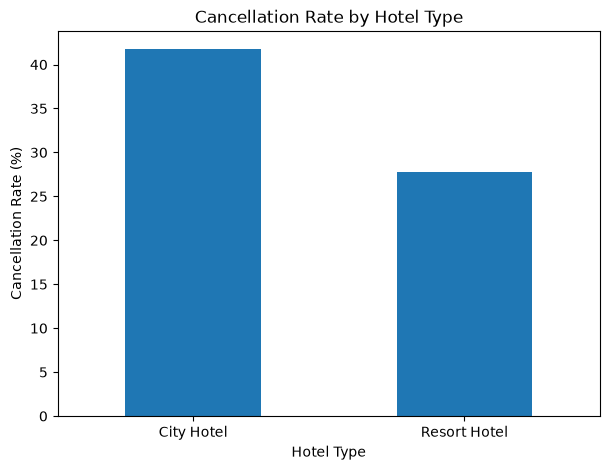

In [34]:
# Visualize cancellation rate by hotel type
cancellation_rates = (
    df.groupby('hotel')['is_canceled'].mean() * 100
)

plt.figure(figsize=(7, 5))

cancellation_rates.plot(kind='bar')

plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Hotel Type Visualization

The bar chart visually confirms that the City Hotel has a higher observed cancellation rate than the Resort Hotel. The difference suggests that `hotel` may be a useful categorical predictor for the cancellation classification task.

This relationship is observational and does not imply that hotel type itself causes booking cancellation.

### 4.2 Lead Time and Cancellation

In [35]:
# Compare lead time between cancelled and non-cancelled bookings
lead_time_summary = df.groupby('is_canceled')['lead_time'].agg(
    Count='count',
    Mean='mean',
    Median='median'
).round(2)

lead_time_summary.index = [
    'Not Cancelled (0)',
    'Cancelled (1)'
]

lead_time_summary

,Count,Mean,Median
Not Cancelled (0),75166,79.98,45.0
Cancelled (1),44224,144.85,113.0


### Lead Time Observation

The lead-time analysis shows a substantial difference between cancelled and non-cancelled bookings.

Non-cancelled bookings have a mean lead time of approximately 79.98 days and a median of 45 days. In comparison, cancelled bookings have a considerably higher mean lead time of approximately 144.85 days and a median of 113 days.

Both the mean and median are higher for cancelled bookings, indicating that bookings made further in advance are associated with cancellation in this dataset. Therefore, `lead_time` may be an important numerical predictor for the cancellation classification task.

This relationship represents an observed association and does not by itself establish a causal relationship.

<Figure size 800x500 with 0 Axes>

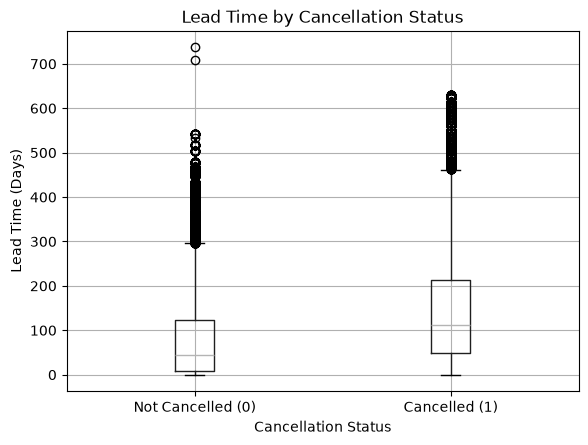

In [36]:
# Compare lead-time distributions by cancellation status
plt.figure(figsize=(8, 5))

df.boxplot(
    column='lead_time',
    by='is_canceled'
)

plt.title('Lead Time by Cancellation Status')
plt.suptitle('')
plt.xlabel('Cancellation Status')
plt.ylabel('Lead Time (Days)')
plt.xticks(
    [1, 2],
    ['Not Cancelled (0)', 'Cancelled (1)']
)

plt.show()

### Interpretation of Lead Time Visualization

The boxplot shows that cancelled bookings generally have higher lead times than non-cancelled bookings. The median and overall distribution of lead time are shifted upward for the cancelled class, supporting the numerical summary calculated previously.

Both cancellation classes also contain high lead-time observations beyond the boxplot whiskers. These represent potential statistical outliers but are not automatically considered invalid records.

Overall, the observed difference between the two groups suggests that `lead_time` may provide useful predictive information for the cancellation classification task.

### 4.3 Deposit Type and Cancellation

In [37]:
# Calculate cancellation statistics by deposit type
deposit_cancellation = df.groupby('deposit_type')['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

deposit_cancellation['Cancellation_Rate (%)'] = (
    deposit_cancellation['Cancellation_Rate'] * 100
).round(2)

deposit_cancellation = deposit_cancellation.drop(
    columns='Cancellation_Rate'
)

deposit_cancellation

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
deposit_type,,,
No Deposit,104641,29694,28.38
Non Refund,14587,14494,99.36
Refundable,162,36,22.22


### Deposit Type Observation

Cancellation rates vary substantially across the different deposit types.

Bookings with `No Deposit` have a cancellation rate of 28.38%, while `Non Refund` bookings have a much higher observed cancellation rate of 99.36%. The `Refundable` category has a cancellation rate of 22.22%.

The `Non Refund` category therefore shows a particularly strong association with the cancellation target in this dataset. This suggests that `deposit_type` may provide important predictive information for the classification task.

However, the `Refundable` category contains only 162 bookings, so its cancellation rate should be interpreted cautiously due to the relatively small number of observations. The observed relationships represent associations and do not establish that deposit type causes cancellation.

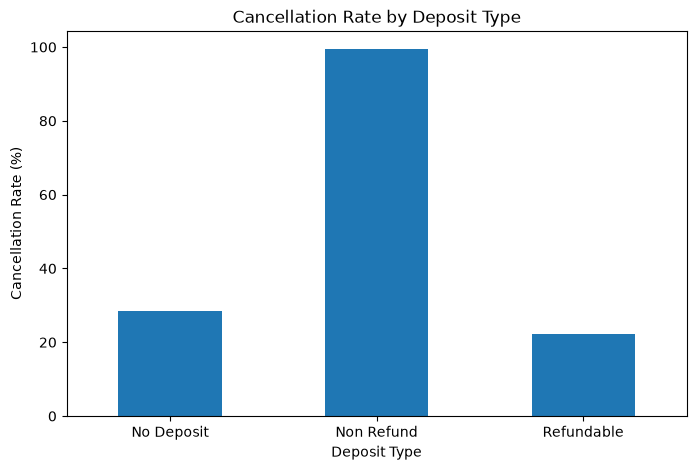

In [38]:
# Visualize cancellation rate by deposit type
deposit_rates = (
    df.groupby('deposit_type')['is_canceled'].mean() * 100
)

plt.figure(figsize=(8, 5))

deposit_rates.plot(kind='bar')

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Deposit Type Visualization

The visualization confirms a substantial difference in cancellation rates across deposit types. The `Non Refund` category has a considerably higher observed cancellation rate than both `No Deposit` and `Refundable`.

This indicates that `deposit_type` has a strong relationship with the target variable and may be an important categorical predictor for the cancellation classification model.

However, the `Refundable` category contains relatively few observations, so its cancellation rate should be interpreted cautiously. The visualization demonstrates an association rather than a causal relationship.

### 4.4 Market Segment and Cancellation

In [39]:
# Calculate cancellation statistics by market segment
market_cancellation = df.groupby('market_segment')['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

market_cancellation['Cancellation_Rate (%)'] = (
    market_cancellation['Cancellation_Rate'] * 100
).round(2)

market_cancellation = market_cancellation.drop(
    columns='Cancellation_Rate'
)

market_cancellation = market_cancellation.sort_values(
    by='Cancellation_Rate (%)',
    ascending=False
)

market_cancellation

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
market_segment,,,
Undefined,2,2,100.00
Groups,19811,12097,61.06
Online TA,56477,20739,36.72
Offline TA/TO,24219,8311,34.32
Aviation,237,52,21.94
Corporate,5295,992,18.73
Direct,12606,1934,15.34
Complementary,743,97,13.06


### Market Segment Observation

Cancellation rates vary across the different market segments.

The `Groups` segment contains 19,811 bookings and has a relatively high cancellation rate of 61.06%. The `Online TA` and `Offline TA/TO` segments also contain substantial numbers of bookings, with cancellation rates of 36.72% and 34.32%, respectively.

Lower observed cancellation rates are found in segments such as `Direct` (15.34%), `Corporate` (18.73%), and `Complementary` (13.06%).

Although the `Undefined` segment has a cancellation rate of 100%, it contains only two observations. Therefore, this percentage should not be interpreted as a reliable pattern.

Overall, the differences across the larger market segments suggest that `market_segment` may provide useful predictive information for the cancellation classification task.

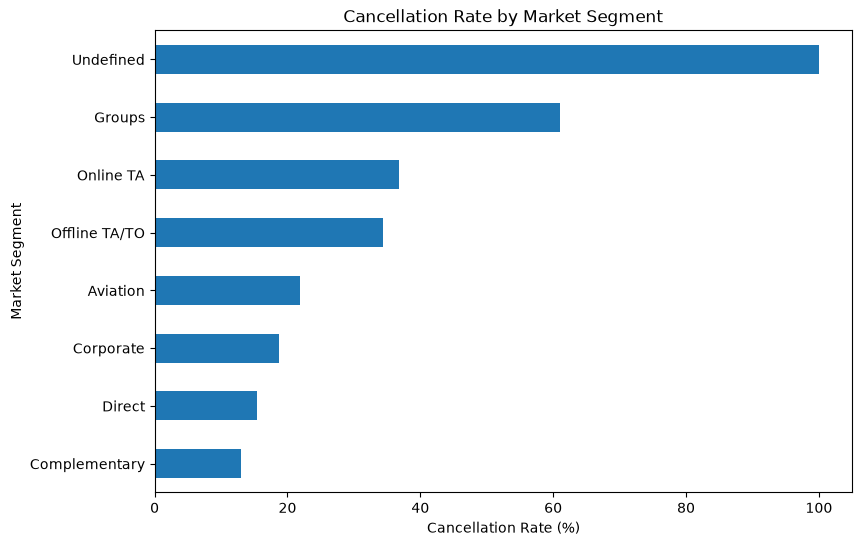

In [40]:
# Visualize cancellation rate by market segment
market_rates = (
    df.groupby('market_segment')['is_canceled'].mean() * 100
).sort_values()

plt.figure(figsize=(9, 6))

market_rates.plot(kind='barh')

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Market Segment')

plt.show()

### Interpretation of Market Segment Visualization

The visualization confirms that cancellation rates differ across market segments. The `Groups` segment shows a relatively high cancellation rate compared with several other major segments, while `Direct`, `Corporate`, and `Complementary` show lower observed cancellation rates.

The `Undefined` category displays a 100% cancellation rate, but this category contains only two bookings. Therefore, this result should be interpreted cautiously and should not be considered a strong pattern based on the percentage alone.

Overall, the observed differences among the larger market segments suggest that `market_segment` may contain useful information for predicting booking cancellations.

### 4.5 Previous Cancellations and Current Booking Cancellation

In [41]:
# Compare bookings based on previous cancellation history
previous_cancel_summary = df.assign(
    Previous_Cancellation_History=np.where(
        df['previous_cancellations'] > 0,
        'One or More',
        'None'
    )
).groupby('Previous_Cancellation_History')['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

previous_cancel_summary['Cancellation_Rate (%)'] = (
    previous_cancel_summary['Cancellation_Rate'] * 100
).round(2)

previous_cancel_summary = previous_cancel_summary.drop(
    columns='Cancellation_Rate'
)

previous_cancel_summary

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
Previous_Cancellation_History,,,
None,112906,38282,33.91
One or More,6484,5942,91.64


### Previous Cancellation History Observation

Bookings with no previous cancellation history have an observed cancellation rate of 33.91%. In comparison, bookings associated with one or more previous cancellations have a substantially higher cancellation rate of 91.64%.

Although the group with previous cancellations is smaller, it still contains 6,484 bookings, of which 5,942 were cancelled.

This indicates a strong association between previous cancellation history and the cancellation status of the current booking. Therefore, `previous_cancellations` may provide useful predictive information for the classification model.

This relationship represents an association observed in the dataset and does not establish that previous cancellations cause a future booking to be cancelled.

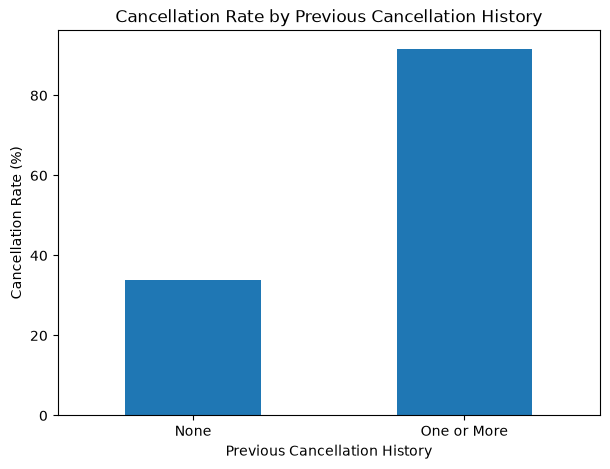

In [42]:
# Visualize cancellation rate by previous cancellation history
previous_cancel_rates = (
    df.assign(
        Previous_Cancellation_History=np.where(
            df['previous_cancellations'] > 0,
            'One or More',
            'None'
        )
    )
    .groupby('Previous_Cancellation_History')['is_canceled']
    .mean() * 100
)

plt.figure(figsize=(7, 5))

previous_cancel_rates.plot(kind='bar')

plt.title('Cancellation Rate by Previous Cancellation History')
plt.xlabel('Previous Cancellation History')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Previous Cancellation History Visualization

The visualization clearly shows that bookings associated with previous cancellations have a substantially higher observed cancellation rate than bookings with no previous cancellation history.

This supports the numerical analysis and suggests that a customer's previous cancellation behaviour may contain useful predictive information for the current booking cancellation classification task.

### 4.6 Special Requests and Cancellation

In [43]:
# Calculate cancellation statistics by number of special requests
special_request_summary = df.groupby(
    'total_of_special_requests'
)['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

special_request_summary['Cancellation_Rate (%)'] = (
    special_request_summary['Cancellation_Rate'] * 100
).round(2)

special_request_summary = special_request_summary.drop(
    columns='Cancellation_Rate'
)

special_request_summary

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
total_of_special_requests,,,
0,70318,33556,47.72
1,33226,7318,22.02
2,12969,2866,22.10
3,2497,446,17.86
4,340,36,10.59
5,40,2,5.00


### Special Requests Observation

The cancellation rate varies noticeably according to the number of special requests associated with a booking.

Bookings with no special requests have the highest observed cancellation rate at 47.72%. Bookings with one or two special requests have considerably lower cancellation rates of approximately 22%, while the observed rate decreases further for bookings with three or more special requests.

This suggests that `total_of_special_requests` may contain useful predictive information for the cancellation classification task.

However, categories with larger numbers of special requests contain relatively few observations. For example, only 40 bookings contain five special requests. Therefore, the very low cancellation rates in these smaller groups should be interpreted cautiously.

The observed pattern represents an association and does not establish that making special requests causes a booking to remain active.

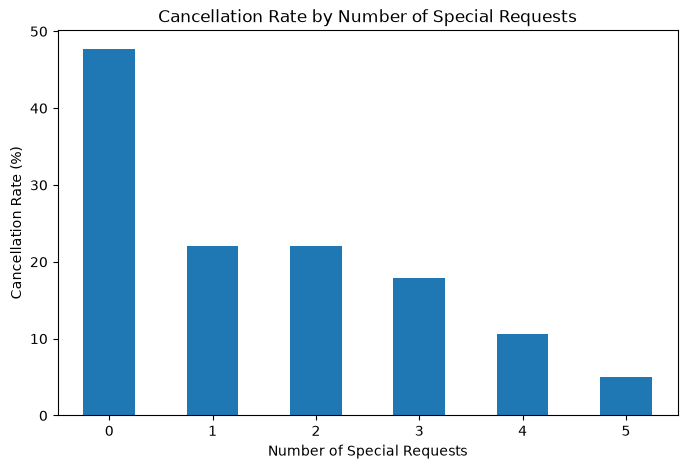

In [44]:
# Visualize cancellation rate by number of special requests
special_request_rates = (
    df.groupby('total_of_special_requests')['is_canceled'].mean() * 100
)

plt.figure(figsize=(8, 5))

special_request_rates.plot(kind='bar')

plt.title('Cancellation Rate by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Special Requests Visualization

The visualization shows that bookings with no special requests have the highest observed cancellation rate. Bookings with one or more special requests generally have lower cancellation rates.

This supports the numerical analysis and suggests that `total_of_special_requests` may contain useful information for predicting booking cancellations.

The categories with four and five special requests contain relatively few observations, so their particularly low cancellation rates should be interpreted cautiously.

### 4.7 Repeated Guest Status and Cancellation

In [45]:
# Calculate cancellation statistics by repeated guest status
repeated_guest_summary = df.groupby(
    'is_repeated_guest'
)['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

repeated_guest_summary['Cancellation_Rate (%)'] = (
    repeated_guest_summary['Cancellation_Rate'] * 100
).round(2)

repeated_guest_summary = repeated_guest_summary.drop(
    columns='Cancellation_Rate'
)

repeated_guest_summary.index = [
    'Not Repeated Guest (0)',
    'Repeated Guest (1)'
]

repeated_guest_summary

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
Not Repeated Guest (0),115580,43672,37.79
Repeated Guest (1),3810,552,14.49


### Repeated Guest Observation

The analysis shows that bookings from non-repeated guests have an observed cancellation rate of 37.79%, while bookings from repeated guests have a considerably lower cancellation rate of 14.49%.

This suggests an association between repeated-guest status and booking cancellation, with repeated guests showing a lower observed cancellation rate in this dataset. Therefore, `is_repeated_guest` may provide useful information for the cancellation classification task.

However, the groups are substantially different in size. Only 3,810 bookings are associated with repeated guests, compared with 115,580 bookings from non-repeated guests. This difference should be considered when interpreting the observed cancellation rates.

The relationship represents an association and does not establish that repeated-guest status itself causes a lower cancellation rate.

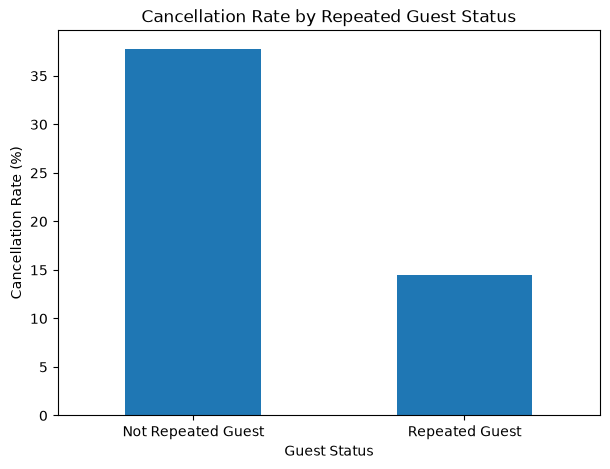

In [46]:
# Visualize cancellation rate by repeated guest status
repeated_guest_rates = (
    df.groupby('is_repeated_guest')['is_canceled'].mean() * 100
)

repeated_guest_rates.index = [
    'Not Repeated Guest',
    'Repeated Guest'
]

plt.figure(figsize=(7, 5))

repeated_guest_rates.plot(kind='bar')

plt.title('Cancellation Rate by Repeated Guest Status')
plt.xlabel('Guest Status')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Repeated Guest Visualization

The visualization confirms that repeated guests have a substantially lower observed cancellation rate than non-repeated guests.

This supports the numerical analysis and suggests that `is_repeated_guest` may be a useful predictor in the cancellation classification task. However, repeated guests represent a much smaller group in the dataset, which should be considered when interpreting the comparison.

### 4.8 Customer Type and Cancellation

In [47]:
# Calculate cancellation statistics by customer type
customer_type_summary = df.groupby(
    'customer_type'
)['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

customer_type_summary['Cancellation_Rate (%)'] = (
    customer_type_summary['Cancellation_Rate'] * 100
).round(2)

customer_type_summary = customer_type_summary.drop(
    columns='Cancellation_Rate'
)

customer_type_summary = customer_type_summary.sort_values(
    by='Cancellation_Rate (%)',
    ascending=False
)

customer_type_summary

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
customer_type,,,
Transient,89613,36514,40.75
Contract,4076,1262,30.96
Transient-Party,25124,6389,25.43
Group,577,59,10.23


### Customer Type Observation

Cancellation rates vary across the different customer types.

`Transient` customers represent the largest category, with 89,613 bookings, and have the highest observed cancellation rate at 40.75%. `Contract` bookings have a cancellation rate of 30.96%, while `Transient-Party` bookings have a lower rate of 25.43%.

The `Group` category has the lowest observed cancellation rate at 10.23%. However, this category contains only 577 bookings, substantially fewer than the other major customer types, so this result should be interpreted cautiously.

Overall, the differences in cancellation rates suggest that `customer_type` may provide useful predictive information for the cancellation classification task.

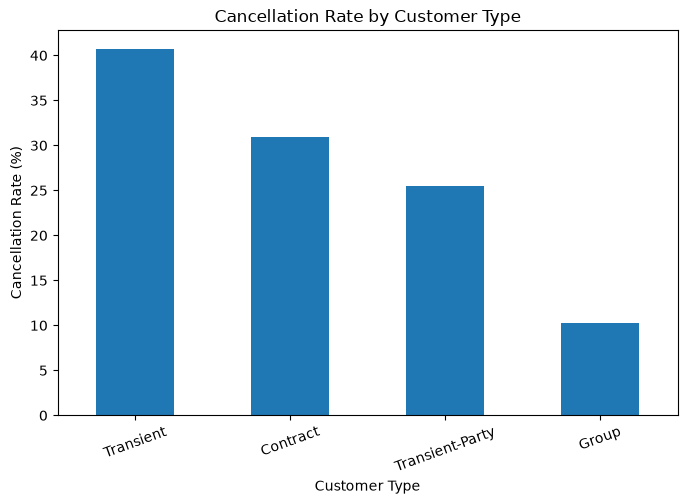

In [48]:
# Visualize cancellation rate by customer type
customer_type_rates = (
    df.groupby('customer_type')['is_canceled'].mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

customer_type_rates.plot(kind='bar')

plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=20)

plt.show()

### Interpretation of Customer Type Visualization

The visualization confirms that cancellation rates differ across customer types. `Transient` customers have the highest observed cancellation rate, followed by `Contract` and `Transient-Party` customers, while the `Group` category has the lowest rate.

This supports the numerical analysis and suggests that `customer_type` may provide useful predictive information for the cancellation classification task. The relatively small number of `Group` bookings should be considered when interpreting its low cancellation rate.

### 4.9 Arrival Month and Cancellation

In [49]:
# Calculate cancellation statistics by arrival month
month_summary = df.groupby(
    'arrival_date_month'
)['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

month_summary['Cancellation_Rate (%)'] = (
    month_summary['Cancellation_Rate'] * 100
).round(2)

month_summary = month_summary.drop(
    columns='Cancellation_Rate'
)

# Arrange months in calendar order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

month_summary = month_summary.reindex(month_order)

month_summary

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
arrival_date_month,,,
January,5929,1807,30.48
February,8068,2696,33.42
March,9794,3149,32.15
April,11089,4524,40.80
May,11791,4677,39.67
June,10939,4535,41.46
July,12661,4742,37.45
August,13877,5239,37.75
September,10508,4116,39.17


### Arrival Month Observation

Cancellation rates vary across arrival months, indicating some seasonal variation in booking cancellation behaviour.

The highest observed cancellation rate occurs in June (41.46%), followed by April (40.80%) and May (39.67%). Lower cancellation rates are observed in months such as January (30.48%), November (31.23%), and March (32.15%).

The differences between months are less extreme than some of the relationships observed for variables such as `deposit_type` and `previous_cancellations`. Nevertheless, the variation suggests that `arrival_date_month` may contain useful seasonal information for the cancellation classification task.

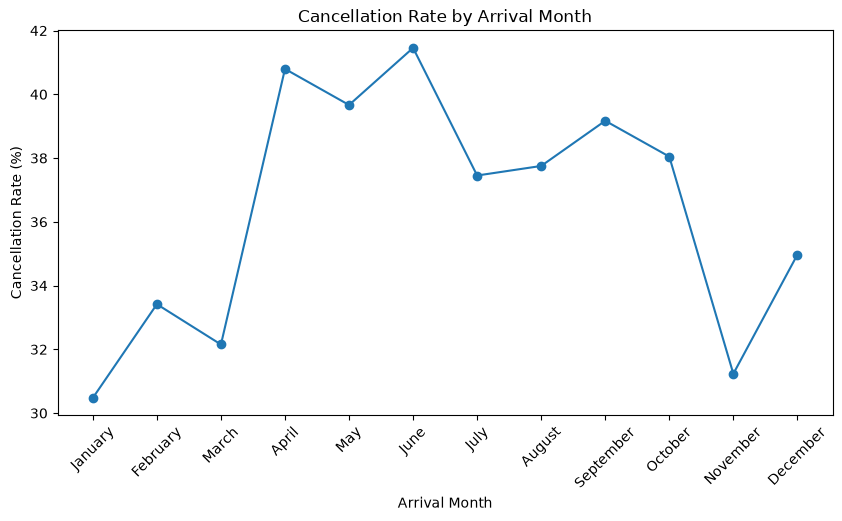

In [50]:
# Visualize cancellation rate across arrival months
month_rates = (
    df.groupby('arrival_date_month')['is_canceled'].mean() * 100
).reindex(month_order)

plt.figure(figsize=(10, 5))

plt.plot(
    month_rates.index,
    month_rates.values,
    marker='o'
)

plt.title('Cancellation Rate by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)

plt.show()

### Interpretation of Arrival Month Visualization

The visualization shows variation in cancellation rates across arrival months. Cancellation rates are relatively lower during January, March, and November, while higher rates are observed during several months in the middle of the year, with June showing the highest observed rate.

This provides evidence of a seasonal pattern in cancellation behaviour and suggests that `arrival_date_month` may contain useful information for the prediction task.

However, the differences are moderate and the monthly values are aggregated across multiple years. Therefore, the pattern should be interpreted as an observed association rather than evidence that a particular month causes cancellations.

### 4.10 Average Daily Rate (ADR) and Cancellation

In [51]:
# Compare ADR between cancelled and non-cancelled bookings
adr_cancellation_summary = df.groupby('is_canceled')['adr'].agg(
    Count='count',
    Mean='mean',
    Median='median'
).round(2)

adr_cancellation_summary.index = [
    'Not Cancelled (0)',
    'Cancelled (1)'
]

adr_cancellation_summary

,Count,Mean,Median
Not Cancelled (0),75166,99.99,92.5
Cancelled (1),44224,104.96,96.2


### ADR and Cancellation Observation

Cancelled bookings have a mean ADR of approximately 104.96 and a median ADR of 96.20. Non-cancelled bookings have a slightly lower mean ADR of approximately 99.99 and a median ADR of 92.50.

Both the mean and median are somewhat higher for cancelled bookings. However, the difference between the two groups is relatively small compared with some of the stronger relationships identified for other variables.

The ADR variable also contains extreme observations identified earlier during the outlier investigation. Therefore, both the mean and median should be considered when interpreting its relationship with cancellation.

Overall, `adr` may contain predictive information, but the summary statistics alone do not indicate a particularly strong separation between cancelled and non-cancelled bookings.

<Figure size 800x500 with 0 Axes>

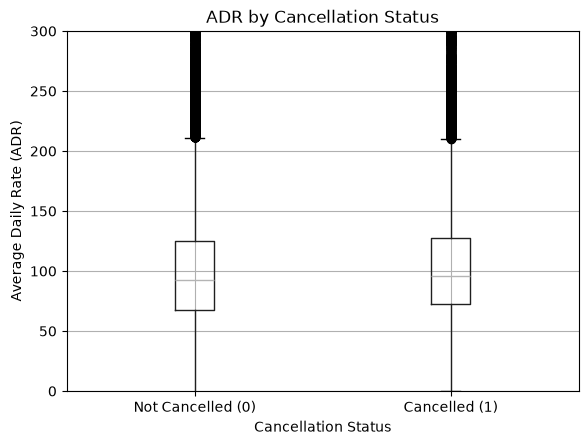

In [52]:
# Compare the main ADR distributions by cancellation status
plt.figure(figsize=(8, 5))

df.boxplot(
    column='adr',
    by='is_canceled'
)

plt.title('ADR by Cancellation Status')
plt.suptitle('')
plt.xlabel('Cancellation Status')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(
    [1, 2],
    ['Not Cancelled (0)', 'Cancelled (1)']
)

# Restrict only the displayed y-axis for clearer visualization
plt.ylim(0, 300)

plt.show()

### Interpretation of ADR Visualization

The boxplot shows substantial overlap between the ADR distributions of cancelled and non-cancelled bookings. The median ADR is slightly higher for cancelled bookings, which is consistent with the numerical summary.

However, the difference between the two groups is relatively small, suggesting that ADR alone does not provide strong separation between cancelled and non-cancelled bookings.

Numerous observations occur above the boxplot whiskers, consistent with the potential ADR outliers identified earlier. The visualization has been restricted to the 0–300 ADR range for readability only; observations outside this range have not been removed from the dataset.

### 4.11 Required Car Parking Spaces and Cancellation

In [53]:
# Compare bookings by parking-space requirement
parking_summary = df.assign(
    Parking_Requirement=np.where(
        df['required_car_parking_spaces'] > 0,
        'One or More',
        'None'
    )
).groupby('Parking_Requirement')['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

parking_summary['Cancellation_Rate (%)'] = (
    parking_summary['Cancellation_Rate'] * 100
).round(2)

parking_summary = parking_summary.drop(
    columns='Cancellation_Rate'
)

parking_summary

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
Parking_Requirement,,,
None,111974,44224,39.49
One or More,7416,0,0.00


### Car Parking Requirement Observation

A substantial difference is observed between bookings with and without required car parking spaces.

Bookings with no required parking spaces have a cancellation rate of 39.49%. In contrast, none of the 7,416 bookings requiring one or more car parking spaces are recorded as cancelled in this dataset.

This indicates a very strong association between `required_car_parking_spaces` and the target variable. Therefore, the variable may provide substantial predictive information for the cancellation classification task.

However, the 0% cancellation rate for bookings requiring parking is an unusually strong pattern and should be interpreted carefully. It does not demonstrate that requesting a parking space prevents cancellation, nor does this relationship alone establish data leakage. The availability and meaning of this variable will be considered when preparing the final predictor set.

In [54]:
# Cross-check exact parking-space values against cancellation status
parking_check = pd.crosstab(
    df['required_car_parking_spaces'],
    df['is_canceled']
)

parking_check.columns = [
    'Not Cancelled (0)',
    'Cancelled (1)'
]

parking_check

,Not Cancelled (0),Cancelled (1)
required_car_parking_spaces,,
0,67750,44224
1,7383,0
2,28,0
3,3,0
8,2,0


### Verification of Car Parking Pattern

The cross-tabulation confirms that all cancelled bookings in the dataset have zero required car parking spaces. Among bookings requiring at least one parking space, no cancellations are recorded.

Most positive parking requirements correspond to one parking space (7,383 bookings), while values of two, three, and eight parking spaces are extremely rare.

This confirms that the previously observed 0% cancellation rate among bookings requiring parking is present in the underlying data and is not caused by the temporary grouping used in the earlier analysis.

The relationship is unusually strong and will therefore be considered carefully during feature selection and leakage assessment before modelling. It should not be interpreted as evidence that requesting parking causes a booking not to be cancelled.

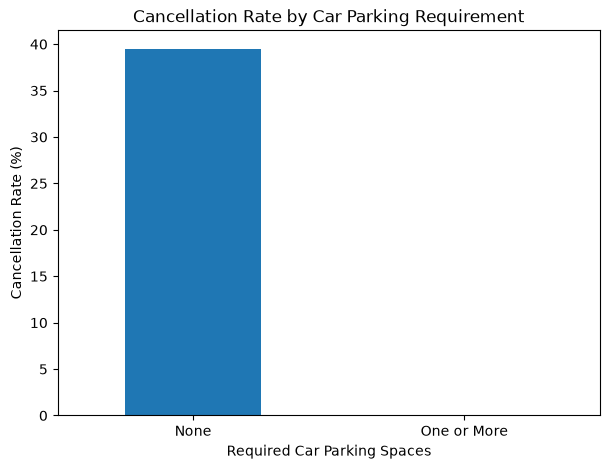

In [55]:
# Visualize cancellation rate by parking requirement
parking_rates = (
    df.assign(
        Parking_Requirement=np.where(
            df['required_car_parking_spaces'] > 0,
            'One or More',
            'None'
        )
    )
    .groupby('Parking_Requirement')['is_canceled']
    .mean() * 100
)

plt.figure(figsize=(7, 5))

parking_rates.plot(kind='bar')

plt.title('Cancellation Rate by Car Parking Requirement')
plt.xlabel('Required Car Parking Spaces')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Car Parking Requirement Visualization

The visualization confirms a very strong association between required car parking spaces and booking cancellation. Bookings with no parking requirement have an observed cancellation rate of 39.49%, while no cancellations are recorded among bookings requiring one or more parking spaces.

This pattern was verified using the individual parking-space values and is present in the underlying dataset. However, the result should not be interpreted as evidence that requesting parking prevents cancellation.

Because the relationship is unusually strong, the variable will be considered carefully during later feature selection and leakage assessment before modelling.

### 4.12 Distribution Channel and Cancellation

In [56]:
# Calculate cancellation statistics by distribution channel
distribution_summary = df.groupby(
    'distribution_channel'
)['is_canceled'].agg(
    Total_Bookings='count',
    Cancelled_Bookings='sum',
    Cancellation_Rate='mean'
)

distribution_summary['Cancellation_Rate (%)'] = (
    distribution_summary['Cancellation_Rate'] * 100
).round(2)

distribution_summary = distribution_summary.drop(
    columns='Cancellation_Rate'
)

distribution_summary = distribution_summary.sort_values(
    by='Cancellation_Rate (%)',
    ascending=False
)

distribution_summary

,Total_Bookings,Cancelled_Bookings,Cancellation_Rate (%)
distribution_channel,,,
Undefined,5,4,80.00
TA/TO,97870,40152,41.03
Corporate,6677,1474,22.08
GDS,193,37,19.17
Direct,14645,2557,17.46


### Distribution Channel Observation

Cancellation rates vary across the different distribution channels.

The `TA/TO` channel represents the largest group with 97,870 bookings and has an observed cancellation rate of 41.03%. In comparison, bookings through the `Direct` channel have a considerably lower cancellation rate of 17.46%, while the `Corporate` channel has a cancellation rate of 22.08%.

The `GDS` category has a cancellation rate of 19.17%, but it contains only 193 bookings. Similarly, the `Undefined` category shows an 80% cancellation rate but contains only five bookings. Therefore, these smaller categories should be interpreted cautiously.

Overall, the differences among the major distribution channels suggest that `distribution_channel` may provide useful predictive information for the cancellation classification task.

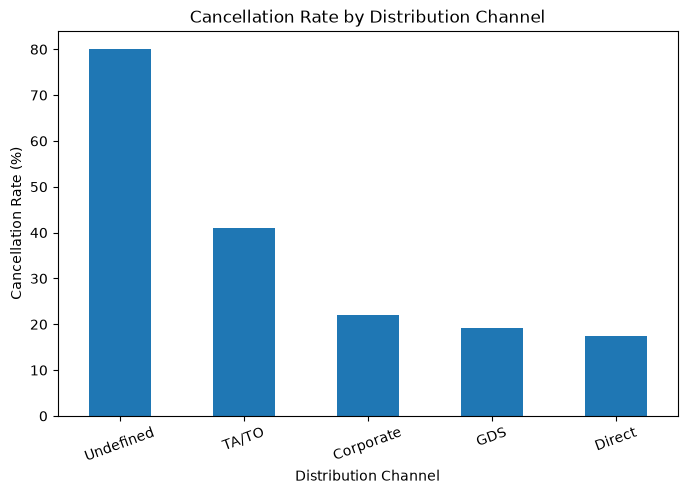

In [57]:
# Visualize cancellation rate by distribution channel
distribution_rates = (
    df.groupby('distribution_channel')['is_canceled'].mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

distribution_rates.plot(kind='bar')

plt.title('Cancellation Rate by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=20)

plt.show()

### Interpretation of Distribution Channel Visualization

The visualization confirms that cancellation rates differ across distribution channels. Among the major channels, `TA/TO` has a considerably higher observed cancellation rate than `Corporate` and `Direct`.

Although the `Undefined` category displays the highest cancellation rate, it contains only five bookings. Therefore, its high percentage should not be interpreted as a reliable general pattern.

Overall, the visualization supports the numerical analysis and suggests that `distribution_channel` may contain useful predictive information for the cancellation classification task.

### 4.13 Length of Stay and Cancellation

In [58]:
# Compare total length of stay by cancellation status
total_stay = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

stay_summary = pd.DataFrame({
    'is_canceled': df['is_canceled'],
    'total_stay': total_stay
}).groupby('is_canceled')['total_stay'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Maximum='max'
).round(2)

stay_summary.index = [
    'Not Cancelled (0)',
    'Cancelled (1)'
]

stay_summary

,Count,Mean,Median,Maximum
Not Cancelled (0),75166,3.39,3.0,69
Cancelled (1),44224,3.49,3.0,56


### Length of Stay Observation

The average total length of stay is approximately 3.39 nights for non-cancelled bookings and 3.49 nights for cancelled bookings. Both groups have a median stay of 3 nights.

The similarity in the mean and median values indicates that overall length of stay does not show a strong difference between cancelled and non-cancelled bookings based on these summary statistics.

The maximum observed stay is 69 nights among non-cancelled bookings and 56 nights among cancelled bookings. These unusually long stays were identified earlier as part of the unusual-value investigation.

Although the relationship with cancellation appears relatively weak, combining `stays_in_weekend_nights` and `stays_in_week_nights` into a `total_stay` feature may still provide a useful and interpretable feature during later feature engineering.

### 4.14 Total Guests and Cancellation

In [59]:
# Compare total number of guests by cancellation status
total_guests = (
    df['adults'] +
    df['children'].fillna(0) +
    df['babies']
)

guest_summary = pd.DataFrame({
    'is_canceled': df['is_canceled'],
    'total_guests': total_guests
}).groupby('is_canceled')['total_guests'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Maximum='max'
).round(2)

guest_summary.index = [
    'Not Cancelled (0)',
    'Cancelled (1)'
]

guest_summary

,Count,Mean,Median,Maximum
Not Cancelled (0),75166,1.94,2.0,12.0
Cancelled (1),44224,2.01,2.0,55.0


### Total Guests Observation

The average total number of guests is approximately 1.94 for non-cancelled bookings and 2.01 for cancelled bookings. Both groups have a median of 2 guests.

The similarity in the mean and median values suggests that total guest count alone does not strongly distinguish between cancelled and non-cancelled bookings.

The maximum value of 55 guests in the cancelled group is associated with the unusual large group bookings identified earlier during the data-quality analysis.

Although the relationship with cancellation appears relatively weak, combining `adults`, `children`, and `babies` into a `total_guests` variable may still provide a useful and interpretable engineered feature during preprocessing.

## 5. Data Preprocessing and Feature Engineering

Based on the findings from the data-understanding, data-quality, EDA, and leakage analyses, appropriate preprocessing steps are now applied to prepare the dataset for machine-learning modelling.

A separate copy of the original dataset is used so that the raw data remains unchanged. Each major preprocessing decision is justified based on the findings identified during the previous analysis.

In [60]:
# Create a separate dataframe for preprocessing
df_processed = df.copy()

print("Original dataset shape:", df.shape)
print("Preprocessing dataset shape:", df_processed.shape)

Original dataset shape: (119390, 32)
Preprocessing dataset shape: (119390, 32)


### 5.1 Removal of Confirmed Leakage Variables

The earlier leakage analysis identified `reservation_status` as a direct source of target leakage because its values perfectly correspond with the final cancellation outcome.

The `reservation_status_date` variable is also associated with the final reservation status and may contain information that becomes available only after the intended prediction point.

Since the objective is to predict cancellation using information available at or near booking confirmation, both variables are excluded from the predictor dataset to prevent outcome-related information from influencing the machine-learning models.

In [61]:
# Remove confirmed outcome-related leakage variables
leakage_columns = [
    'reservation_status',
    'reservation_status_date'
]

df_processed = df_processed.drop(columns=leakage_columns)

print("Shape after removing confirmed leakage variables:",
      df_processed.shape)

print("\nRemoved columns:")
print(leakage_columns)

print("\nAre leakage columns still present?")
for column in leakage_columns:
    print(column, ":", column in df_processed.columns)

Shape after removing confirmed leakage variables: (119390, 30)

Removed columns:
['reservation_status', 'reservation_status_date']

Are leakage columns still present?
reservation_status : False
reservation_status_date : False


### 5.2 Removal of Timing-Sensitive Variables

The variables `assigned_room_type`, `booking_changes`, and `days_in_waiting_list` were identified during the leakage analysis as timing-sensitive variables.

Unlike `reservation_status`, these variables do not directly reveal the cancellation outcome. However, their final recorded values may only become available after the initial booking or may change during the booking lifecycle.

This project defines the intended prediction point as at or near booking confirmation. Therefore, to maintain a consistent prediction-time feature set and reduce the risk of using future information, these timing-sensitive variables are excluded from the predictor dataset.

The corresponding booking-time information is retained where appropriate. For example, `reserved_room_type` is retained because it represents the room type requested when the reservation was made.

In [62]:
# Remove timing-sensitive variables
timing_sensitive_columns = [
    'assigned_room_type',
    'booking_changes',
    'days_in_waiting_list'
]

df_processed = df_processed.drop(
    columns=timing_sensitive_columns
)

print("Shape after removing timing-sensitive variables:",
      df_processed.shape)

print("\nRemoved timing-sensitive columns:")
print(timing_sensitive_columns)

print("\nAre these columns still present?")
for column in timing_sensitive_columns:
    print(column, ":", column in df_processed.columns)

Shape after removing timing-sensitive variables: (119390, 27)

Removed timing-sensitive columns:
['assigned_room_type', 'booking_changes', 'days_in_waiting_list']

Are these columns still present?
assigned_room_type : False
booking_changes : False
days_in_waiting_list : False


### 5.3 Missing-Value Treatment

#### Company Variable

The `company` variable contains 112,593 missing values, representing approximately 94.31% of the dataset. In addition, the variable represents a company identifier/code rather than a continuous numerical measurement.

Because only a very small proportion of bookings contain a recorded company value, imputing the missing values would require making assumptions for the majority of the dataset and may provide limited meaningful information.

Therefore, `company` is removed from the preprocessing dataset due to its extremely high missingness and identifier-like nature.

In [63]:
# Remove company due to extremely high missingness
df_processed = df_processed.drop(columns=['company'])

print("Shape after removing company:",
      df_processed.shape)

print("Is company still present?",
      'company' in df_processed.columns)

Shape after removing company: (119390, 26)
Is company still present? False


#### Agent Variable

The `agent` variable contains approximately 13.69% missing values and represents an agent identifier/code rather than a continuous numerical measurement.

Unlike `company`, its missingness is not sufficiently high to justify immediate removal based only on missing values. Therefore, the distribution of the recorded agent codes is examined before making the final preprocessing decision.

In [64]:
# Investigate the agent variable before deciding how to handle it

print("Missing agent values:",
      df_processed['agent'].isna().sum())

print("Missing percentage:",
      round(df_processed['agent'].isna().mean() * 100, 2), "%")

print("\nNumber of unique recorded agents:",
      df_processed['agent'].nunique())

print("\n10 most frequent agent codes:")
print(df_processed['agent'].value_counts().head(10))

print("\nPercentage represented by the 10 most frequent agents:")
top10_percentage = (
    df_processed['agent'].value_counts().head(10).sum()
    / df_processed['agent'].notna().sum()
    * 100
)

print(round(top10_percentage, 2), "%")

Missing agent values: 16340
Missing percentage: 13.69 %

Number of unique recorded agents: 333

10 most frequent agent codes:
agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
8.0       1514
Name: count, dtype: int64

Percentage represented by the 10 most frequent agents:
69.2 %


#### Agent Variable Decision

The `agent` variable contains 16,340 missing values (13.69%) and 333 unique recorded agent codes. The ten most frequent agents account for approximately 69.2% of the non-missing observations.

Although the variable contains some information, it represents an identifier/code rather than a meaningful numerical quantity. Retaining it as a categorical variable would introduce relatively high cardinality and substantially increase the number of encoded features.

Furthermore, other variables such as `market_segment` and `distribution_channel` provide more interpretable information about how the booking was made.

Therefore, `agent` is excluded from the predictor dataset to reduce unnecessary complexity and avoid treating arbitrary identifier codes as numerical information.

In [65]:
# Remove agent because it is a high-cardinality identifier/code
df_processed = df_processed.drop(columns=['agent'])

print("Shape after removing agent:",
      df_processed.shape)

print("Is agent still present?",
      'agent' in df_processed.columns)

Shape after removing agent: (119390, 25)
Is agent still present? False


#### Country Variable

The `country` variable contains 488 missing values, representing approximately 0.41% of the dataset.

Since `country` is a categorical variable, assigning the most frequent country would assume information that is not available. Removing the affected rows would also unnecessarily discard otherwise usable booking records.

Therefore, missing `country` values are represented using a separate `Unknown` category. This preserves the observations while explicitly indicating that the country information was unavailable.

In [66]:
# Replace missing country values with an explicit category
df_processed['country'] = df_processed['country'].fillna('Unknown')

print("Missing country values after treatment:",
      df_processed['country'].isna().sum())

print("Number of 'Unknown' country records:",
      (df_processed['country'] == 'Unknown').sum())

Missing country values after treatment: 0
Number of 'Unknown' country records: 488


#### Children Variable

The `children` variable contains only four missing values, representing a negligible proportion of the dataset.

Since `children` is a numerical count variable and only a very small number of observations are affected, the missing values are imputed using the median of the available `children` values. The median is preferred because it is less sensitive to unusual values than the mean.

This approach preserves the affected booking records without introducing substantial changes to the distribution of the variable.

In [67]:
# Check the median before imputation
children_median = df_processed['children'].median()

print("Median number of children:", children_median)
print("Missing values before:", df_processed['children'].isna().sum())

# Fill missing children values with the median
df_processed['children'] = (
    df_processed['children'].fillna(children_median)
)

print("Missing values after:", df_processed['children'].isna().sum())

Median number of children: 0.0
Missing values before: 4
Missing values after: 0


#### Verification of Missing-Value Treatment

After applying the selected missing-value treatments, the dataset is checked again to confirm whether any missing values remain.

In [68]:
# Verify remaining missing values
remaining_missing = df_processed.isnull().sum()

print("Columns with remaining missing values:")
print(remaining_missing[remaining_missing > 0])

print("\nTotal remaining missing values:",
      df_processed.isnull().sum().sum())

print("\nCurrent dataset shape:",
      df_processed.shape)

Columns with remaining missing values:
Series([], dtype: int64)

Total remaining missing values: 0

Current dataset shape: (119390, 25)


### 5.4 Duplicate Record Treatment

The initial data-quality analysis identified a substantial number of exact duplicate rows. However, the dataset does not contain a unique booking identifier. Therefore, identical records cannot automatically be assumed to represent erroneous duplicate bookings.

Since several variables have also been removed during preprocessing, duplicate records are re-evaluated using the current preprocessing dataset before deciding on an appropriate treatment.

In [69]:
# Recheck exact duplicates after the preprocessing performed so far
duplicate_count = df_processed.duplicated().sum()
duplicate_percentage = (
    duplicate_count / len(df_processed) * 100
)

print("Current number of exact duplicate rows:",
      duplicate_count)

print("Percentage of current dataset:",
      round(duplicate_percentage, 2), "%")

print("Current dataset shape:",
      df_processed.shape)

Current number of exact duplicate rows: 34091
Percentage of current dataset: 28.55 %
Current dataset shape: (119390, 25)


#### Duplicate Record Decision

After the previous preprocessing steps, 34,091 exact duplicate rows were identified, representing approximately 28.55% of the current dataset.

This number is slightly higher than the duplicate count observed in the original dataset because several variables were removed during preprocessing. Consequently, some records that were previously distinguishable may now have identical values across the retained variables.

The dataset does not contain a unique booking identifier, so it is not possible to confirm that every identical record represents an erroneous duplicate booking. Nevertheless, retaining exact duplicate observations may cause identical processed records to occur in both the training and testing sets after a random split. This could make model evaluation overly optimistic and may also give repeated observations excessive influence during training.

Therefore, exact duplicate rows in the current preprocessing dataset are removed before the train-test split. One copy of each identical record is retained.

In [70]:
# Remove exact duplicate records
rows_before = len(df_processed)

df_processed = df_processed.drop_duplicates().reset_index(drop=True)

rows_after = len(df_processed)
rows_removed = rows_before - rows_after

print("Rows before duplicate removal:", rows_before)
print("Rows removed:", rows_removed)
print("Rows after duplicate removal:", rows_after)

print("\nRemaining exact duplicates:",
      df_processed.duplicated().sum())

print("\nCurrent dataset shape:",
      df_processed.shape)

Rows before duplicate removal: 119390
Rows removed: 34091
Rows after duplicate removal: 85299

Remaining exact duplicates: 0

Current dataset shape: (85299, 25)


### 5.5 Invalid Record Treatment

During the data-quality analysis, records with zero total guests were identified. A booking containing no adults, children, or babies does not represent a meaningful guest composition for the intended hotel-booking prediction scenario.

Since duplicate records have now been removed, the number of zero-guest observations is rechecked on the current preprocessing dataset before applying any treatment.

In [71]:
# Recheck zero-guest bookings after duplicate removal
zero_guest_mask = (
    (df_processed['adults'] == 0) &
    (df_processed['children'] == 0) &
    (df_processed['babies'] == 0)
)

zero_guest_count = zero_guest_mask.sum()

print("Zero-guest records in current dataset:",
      zero_guest_count)

print("Percentage of current dataset:",
      round(zero_guest_count / len(df_processed) * 100, 3), "%")

print("\nCancellation distribution of zero-guest records:")
print(
    df_processed.loc[
        zero_guest_mask, 'is_canceled'
    ].value_counts().sort_index()
)

Zero-guest records in current dataset: 163
Percentage of current dataset: 0.191 %

Cancellation distribution of zero-guest records:
is_canceled
0    147
1     16
Name: count, dtype: int64


#### Zero-Guest Records

After duplicate removal, 163 records (approximately 0.191% of the current dataset) contain zero total guests, meaning that `adults`, `children`, and `babies` are all recorded as zero.

Of these records, 147 are non-cancelled and 16 are cancelled. Regardless of cancellation status, a booking with no recorded guests does not represent a meaningful guest composition for the intended hotel-booking prediction scenario.

Since these records represent a very small proportion of the dataset and have an invalid guest composition, they are removed from the preprocessing dataset.

In [72]:
# Remove records with zero total guests
rows_before = len(df_processed)

zero_guest_mask = (
    (df_processed['adults'] == 0) &
    (df_processed['children'] == 0) &
    (df_processed['babies'] == 0)
)

df_processed = (
    df_processed.loc[~zero_guest_mask]
    .reset_index(drop=True)
)

rows_after = len(df_processed)

print("Rows before:", rows_before)
print("Zero-guest rows removed:", rows_before - rows_after)
print("Rows after:", rows_after)

# Verify
remaining_zero_guests = (
    (df_processed['adults'] == 0) &
    (df_processed['children'] == 0) &
    (df_processed['babies'] == 0)
).sum()

print("Remaining zero-guest records:",
      remaining_zero_guests)

print("Current dataset shape:",
      df_processed.shape)

Rows before: 85299
Zero-guest rows removed: 163
Rows after: 85136
Remaining zero-guest records: 0
Current dataset shape: (85136, 25)


#### Zero-Night Stay Investigation

Records with zero total stay were identified during the initial data-quality analysis. Unlike zero-guest records, a zero-night stay is not automatically considered invalid because it may represent a booking that did not result in an overnight stay.

Therefore, these records are investigated further before deciding whether any treatment is necessary.

In [73]:
# Investigate zero-night stays in the current dataset
total_nights = (
    df_processed['stays_in_weekend_nights'] +
    df_processed['stays_in_week_nights']
)

zero_night_mask = total_nights == 0

print("Zero-night records:",
      zero_night_mask.sum())

print("Percentage of current dataset:",
      round(zero_night_mask.mean() * 100, 3), "%")

print("\nCancellation distribution:")
print(
    df_processed.loc[
        zero_night_mask, 'is_canceled'
    ].value_counts().sort_index()
)

print("\nCancellation rate:")
print(
    round(
        df_processed.loc[
            zero_night_mask, 'is_canceled'
        ].mean() * 100,
        2
    ),
    "%"
)

Zero-night records: 582
Percentage of current dataset: 0.684 %

Cancellation distribution:
is_canceled
0    559
1     23
Name: count, dtype: int64

Cancellation rate:
3.95 %


#### Zero-Night Stay Decision

After duplicate and invalid zero-guest records were handled, 582 bookings (approximately 0.684% of the current dataset) have zero recorded weekend and weekday nights.

Among these records, 559 are non-cancelled and 23 are cancelled, corresponding to an observed cancellation rate of approximately 3.95%.

Unlike bookings with zero recorded guests, zero-night bookings cannot be confidently classified as invalid based solely on the available dataset. They may represent bookings that did not result in a recorded overnight stay or other valid booking circumstances.

Therefore, the zero-night records are retained rather than removed, since there is insufficient evidence to classify them as data errors.

In [74]:
# Recheck unusual ADR values in the current dataset
print("Minimum ADR:", df_processed['adr'].min())
print("Maximum ADR:", df_processed['adr'].max())

print("\nNegative ADR records:",
      (df_processed['adr'] < 0).sum())

print("ADR greater than 500:",
      (df_processed['adr'] > 500).sum())

print("ADR greater than 1000:",
      (df_processed['adr'] > 1000).sum())

print("\nHighest 10 ADR values:")
print(
    df_processed['adr']
    .sort_values(ascending=False)
    .head(10)
    .to_string(index=False)
)

Minimum ADR: -6.38
Maximum ADR: 5400.0

Negative ADR records: 1
ADR greater than 500: 3
ADR greater than 1000: 1

Highest 10 ADR values:
5400.00
 510.00
 508.00
 451.50
 450.00
 437.00
 426.25
 402.00
 397.38
 392.00


#### ADR Outlier Treatment

The `adr` variable was examined because the initial EDA identified both statistical outliers and unusual extreme values.

In the current preprocessing dataset, one booking has a negative ADR value of -6.38. Since ADR represents an average daily rate, a negative value is not considered meaningful for the intended modelling context. As only one observation is affected, this record is removed.

Several unusually high positive ADR values are also present, including a maximum value of 5400. However, high ADR values are not automatically considered invalid because legitimate room rates can vary substantially. Therefore, positive ADR outliers are not removed solely based on the IQR rule. Extreme positive values are considered separately to avoid unnecessarily discarding valid observations.

In [75]:
# Remove the single record with a negative ADR
rows_before = len(df_processed)

df_processed = (
    df_processed[df_processed['adr'] >= 0]
    .reset_index(drop=True)
)

rows_after = len(df_processed)

print("Rows before:", rows_before)
print("Negative ADR rows removed:", rows_before - rows_after)
print("Rows after:", rows_after)

print("Remaining negative ADR records:",
      (df_processed['adr'] < 0).sum())

print("Current dataset shape:",
      df_processed.shape)

Rows before: 85136
Negative ADR rows removed: 1
Rows after: 85135
Remaining negative ADR records: 0
Current dataset shape: (85135, 25)


In [76]:
# Inspect the booking with the extremely high ADR value
extreme_adr_record = df_processed.loc[
    df_processed['adr'] == df_processed['adr'].max(),
    [
        'hotel',
        'is_canceled',
        'lead_time',
        'arrival_date_year',
        'arrival_date_month',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'adults',
        'children',
        'babies',
        'market_segment',
        'reserved_room_type',
        'deposit_type',
        'customer_type',
        'adr'
    ]
]

extreme_adr_record

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,market_segment,reserved_room_type,deposit_type,customer_type,adr
37639,City Hotel,1,35,2016,March,0,1,2,0.0,0,Offline TA/TO,A,Non Refund,Transient,5400.0


#### Extreme ADR Observation

Further inspection of the maximum ADR observation showed a value of 5400 for a one-night City Hotel booking involving two adults. The next-highest ADR values in the dataset are approximately 510 and 508.

The value of 5400 is therefore exceptionally separated from the rest of the observed ADR values and may represent an anomalous recording. Such an extreme value could disproportionately influence algorithms that are sensitive to numerical magnitude.

Therefore, this single extreme ADR observation is removed. Other high positive ADR values are retained because high room rates are not automatically considered invalid and there is insufficient evidence to justify removing them.

In [77]:
# Remove the single extreme ADR observation of 5400
rows_before = len(df_processed)

df_processed = (
    df_processed[df_processed['adr'] < 5400]
    .reset_index(drop=True)
)

rows_after = len(df_processed)

print("Rows before:", rows_before)
print("Extreme ADR rows removed:", rows_before - rows_after)
print("Rows after:", rows_after)

print("Maximum ADR after treatment:",
      df_processed['adr'].max())

print("Current dataset shape:",
      df_processed.shape)

Rows before: 85135
Extreme ADR rows removed: 1
Rows after: 85134
Maximum ADR after treatment: 510.0
Current dataset shape: (85134, 25)


### 5.6 Feature Engineering

Two additional features are created based on the existing booking information.

`total_stay` combines `stays_in_weekend_nights` and `stays_in_week_nights` to represent the total number of nights associated with the booking.

`total_guests` combines `adults`, `children`, and `babies` to represent the total number of recorded guests.

These features provide simple and interpretable summaries of booking size and stay duration. The original component variables are retained at this stage so that no potentially useful information is discarded prematurely.

In [78]:
# Create total length of stay
df_processed['total_stay'] = (
    df_processed['stays_in_weekend_nights'] +
    df_processed['stays_in_week_nights']
)

# Create total number of guests
df_processed['total_guests'] = (
    df_processed['adults'] +
    df_processed['children'] +
    df_processed['babies']
)

print("New dataset shape:",
      df_processed.shape)

print("\nEngineered features:")
print(
    df_processed[
        ['total_stay', 'total_guests']
    ].describe()
)

print("\nFirst 5 values:")
print(
    df_processed[
        ['total_stay', 'total_guests']
    ].head()
)

New dataset shape: (85134, 27)

Engineered features:
         total_stay  total_guests
count  85134.000000  85134.000000
mean       3.643350      2.036719
std        2.753867      0.793366
min        0.000000      1.000000
25%        2.000000      2.000000
50%        3.000000      2.000000
75%        5.000000      2.000000
max       69.000000     55.000000

First 5 values:
   total_stay  total_guests
0           0           2.0
1           0           2.0
2           1           1.0
3           1           1.0
4           2           2.0


### 5.7 Separation of Predictors and Target Variable

The target variable `is_canceled` is separated from the predictor variables before model preparation.

`X` contains the features that will be used to predict cancellation, while `y` contains the binary target variable, where 0 represents a non-cancelled booking and 1 represents a cancelled booking.

Separating the target at this stage ensures that it is not accidentally included in feature transformations such as categorical encoding or numerical scaling.

In [79]:
# Separate predictors and target
X = df_processed.drop(columns=['is_canceled'])
y = df_processed['is_canceled']

print("Predictor shape (X):", X.shape)
print("Target shape (y):", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Predictor shape (X): (85134, 26)
Target shape (y): (85134,)

Target distribution:
is_canceled
0    61563
1    23571
Name: count, dtype: int64

Target percentages:
is_canceled
0    72.31
1    27.69
Name: proportion, dtype: float64


#### Target Distribution After Preprocessing

After the cleaning and preprocessing steps performed so far, the dataset contains 85,134 observations.

The target distribution is now approximately 72.31% non-cancelled bookings and 27.69% cancelled bookings. This differs from the original dataset distribution because duplicate and invalid records were removed during preprocessing.

The target therefore shows a moderate class imbalance. No artificial balancing technique is applied at this stage. The train-test split will preserve the class proportions using stratification, and later model evaluation should consider metrics beyond accuracy, such as precision, recall, F1-score, and ROC-AUC.

### 5.8 Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. Stratified sampling is applied using the target variable so that the cancellation-class proportions are preserved in both subsets.

A fixed `random_state` is used to make the split reproducible.

The split is performed before fitting categorical encoders or numerical scalers. This is important for preventing data leakage because preprocessing parameters should be learned from the training data rather than from information contained in the test set.

In [80]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train shape: (68107, 26)
X_test shape: (17027, 26)
y_train shape: (68107,)
y_test shape: (17027,)

Training target percentages:
is_canceled
0    72.31
1    27.69
Name: proportion, dtype: float64

Testing target percentages:
is_canceled
0    72.31
1    27.69
Name: proportion, dtype: float64


In [81]:
# Identify categorical and numerical predictor columns

categorical_columns = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_columns = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Number of categorical features:",
      len(categorical_columns))

print("\nCategorical features:")
print(categorical_columns)

print("\nNumber of numerical features:",
      len(numerical_columns))

print("\nNumerical features:")
print(numerical_columns)

print("\nTotal features:",
      len(categorical_columns) + len(numerical_columns))

Number of categorical features: 9

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']

Number of numerical features: 17

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests']

Total features: 26


C:\Users\DELL\AppData\Local\Temp\ipykernel_22556\2978379628.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(


In [82]:
# Inspect the ranges of numerical features before deciding scaling

numeric_summary = X_train[numerical_columns].agg(
    ['min', 'max', 'mean', 'std']
).T

numeric_summary.round(2)

,min,max,mean,std
lead_time,0.0,737.0,78.86,85.06
arrival_date_year,2015.0,2017.0,2016.22,0.68
arrival_date_week_number,1.0,53.0,26.77,13.67
arrival_date_day_of_month,1.0,31.0,15.79,8.85
stays_in_weekend_nights,0.0,19.0,1.01,1.03
stays_in_week_nights,0.0,50.0,2.63,2.05
adults,0.0,55.0,1.88,0.64
children,0.0,10.0,0.14,0.46
babies,0.0,10.0,0.01,0.11
is_repeated_guest,0.0,1.0,0.04,0.19


### 5.9 Categorical Encoding and Numerical Scaling Strategy

The predictor variables contain both categorical and numerical features. Categorical variables will be converted into machine-readable form using one-hot encoding. One-hot encoding is appropriate because these categories do not have a natural ordinal ranking.

The numerical features have substantially different ranges. For example, `lead_time` ranges from 0 to 737 and `adr` ranges up to 510, while several other numerical variables have much smaller ranges. Therefore, numerical scaling is appropriate for algorithms that are sensitive to feature magnitude, such as Logistic Regression, K-Nearest Neighbours, and Support Vector Machines.

The binary variable `is_repeated_guest` is already represented as 0 and 1 and is therefore retained without scaling.

To prevent data leakage, the encoder and scaler will be fitted using the training data only. The fitted transformations can then be applied to the test data.

In [83]:
# Binary feature retained without scaling
binary_columns = ['is_repeated_guest']

# Numerical features to be scaled
numerical_columns_to_scale = [
    col for col in numerical_columns
    if col not in binary_columns
]

print("Categorical features:", len(categorical_columns))
print(categorical_columns)

print("\nNumerical features to scale:",
      len(numerical_columns_to_scale))
print(numerical_columns_to_scale)

print("\nBinary features kept unchanged:")
print(binary_columns)

print("\nTotal features accounted for:",
      len(categorical_columns) +
      len(numerical_columns_to_scale) +
      len(binary_columns))

Categorical features: 9
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']

Numerical features to scale: 16
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests']

Binary features kept unchanged:
['is_repeated_guest']

Total features accounted for: 26


#### Preprocessing Transformer

A `ColumnTransformer` is used to apply different preprocessing operations to different feature types.

Categorical features are transformed using one-hot encoding with `handle_unknown='ignore'`. This allows categories that may appear in the test set but were not observed during training to be handled safely.

Numerical features are standardized using `StandardScaler`, which transforms them to a comparable scale based on statistics learned from the training data.

The binary `is_repeated_guest` feature is passed through unchanged because it is already represented as 0 and 1.

The preprocessing transformer is fitted only on the training data. The same fitted transformer is then applied to the test data, preventing information from the test set from influencing the preprocessing parameters.

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_columns
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_columns_to_scale
        ),
        (
            'binary',
            'passthrough',
            binary_columns
        )
    ]
)

# Fit ONLY on training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

print("\nTraining and testing have the same number of processed features:",
      X_train_processed.shape[1] == X_test_processed.shape[1])

Original X_train shape: (68107, 26)
Processed X_train shape: (68107, 241)

Original X_test shape: (17027, 26)
Processed X_test shape: (17027, 241)

Training and testing have the same number of processed features: True


### 5.10 Validation of the Processed Data

After applying categorical encoding and numerical scaling, the transformed training and testing datasets are checked for missing and infinite values.

This final validation ensures that the processed feature matrices are suitable for machine-learning algorithms and confirms that the same preprocessing structure has been applied consistently to both the training and testing data.

In [85]:
# Check the final processed datasets for missing and infinite values

import numpy as np

print("Training data:")
print("NaN values:",
      np.isnan(X_train_processed.data).sum()
      if hasattr(X_train_processed, 'data')
      else np.isnan(X_train_processed).sum())

print("Infinite values:",
      np.isinf(X_train_processed.data).sum()
      if hasattr(X_train_processed, 'data')
      else np.isinf(X_train_processed).sum())

print("\nTesting data:")
print("NaN values:",
      np.isnan(X_test_processed.data).sum()
      if hasattr(X_test_processed, 'data')
      else np.isnan(X_test_processed).sum())

print("Infinite values:",
      np.isinf(X_test_processed.data).sum()
      if hasattr(X_test_processed, 'data')
      else np.isinf(X_test_processed).sum())

Training data:
NaN values: 0
Infinite values: 0

Testing data:
NaN values: 0
Infinite values: 0


In [86]:
# Examine relationships between engineered features
# and their original component variables

stay_features = [
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'total_stay'
]

guest_features = [
    'adults',
    'children',
    'babies',
    'total_guests'
]

print("Stay-related correlations:")
print(
    X_train[stay_features]
    .corr()
    .round(3)
)

print("\nGuest-related correlations:")
print(
    X_train[guest_features]
    .corr()
    .round(3)
)

Stay-related correlations:
                         stays_in_weekend_nights  stays_in_week_nights  \
stays_in_weekend_nights                    1.000                 0.555   
stays_in_week_nights                       0.555                 1.000   
total_stay                                 0.786                 0.950   

                         total_stay  
stays_in_weekend_nights       0.786  
stays_in_week_nights          0.950  
total_stay                    1.000  

Guest-related correlations:
              adults  children  babies  total_guests
adults         1.000     0.019   0.017         0.805
children       0.019     1.000   0.016         0.592
babies         0.017     0.016   1.000         0.162
total_guests   0.805     0.592   0.162         1.000


### 5.11 Feature Selection and Redundancy Reduction

Correlation analysis showed that the engineered features are strongly related to their original component variables. In particular, `total_stay` has a correlation of 0.950 with `stays_in_week_nights`, while `total_guests` has a correlation of 0.805 with `adults`.

More importantly, the engineered features are exact mathematical combinations of their components. Retaining both the totals and every component would therefore introduce unnecessary redundancy.

To produce a simpler and more interpretable feature set, `total_stay` is retained while `stays_in_weekend_nights` and `stays_in_week_nights` are removed. Similarly, `total_guests` is retained while `adults`, `children`, and `babies` are removed.

This feature-selection decision reduces redundancy while preserving overall information about booking duration and party size.

In [87]:
# Define redundant component features for removal
redundant_features = [
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies'
]

print("Features proposed for removal:")
print(redundant_features)

print("\nNumber of predictors before feature selection:",
      X_train.shape[1])

print("Expected predictors after feature selection:",
      X_train.shape[1] - len(redundant_features))

Features proposed for removal:
['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies']

Number of predictors before feature selection: 26
Expected predictors after feature selection: 21


In [88]:
# Remove redundant component features
X_train_selected = X_train.drop(
    columns=redundant_features
)

X_test_selected = X_test.drop(
    columns=redundant_features
)

print("X_train before feature selection:",
      X_train.shape)

print("X_train after feature selection:",
      X_train_selected.shape)

print("\nX_test before feature selection:",
      X_test.shape)

print("X_test after feature selection:",
      X_test_selected.shape)

print("\nRemoved features still present in training data:")
print([
    col for col in redundant_features
    if col in X_train_selected.columns
])

X_train before feature selection: (68107, 26)
X_train after feature selection: (68107, 21)

X_test before feature selection: (17027, 26)
X_test after feature selection: (17027, 21)

Removed features still present in training data:
[]


In [89]:
# Re-identify feature types after feature selection

categorical_columns_selected = (
    X_train_selected
    .select_dtypes(include=['object'])
    .columns
    .tolist()
)

binary_columns_selected = [
    'is_repeated_guest'
]

numerical_columns_selected = [
    col for col in
    X_train_selected.select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()
    if col not in binary_columns_selected
]

print("Categorical features:",
      len(categorical_columns_selected))
print(categorical_columns_selected)

print("\nNumerical features to scale:",
      len(numerical_columns_selected))
print(numerical_columns_selected)

print("\nBinary features kept unchanged:")
print(binary_columns_selected)

print("\nTotal features accounted for:",
      len(categorical_columns_selected) +
      len(numerical_columns_selected) +
      len(binary_columns_selected))

Categorical features: 9
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']

Numerical features to scale: 11
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests']

Binary features kept unchanged:
['is_repeated_guest']

Total features accounted for: 21


C:\Users\DELL\AppData\Local\Temp\ipykernel_22556\483760934.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=['object'])


In [90]:
# Build the final preprocessing transformer
# using the selected 21 predictors

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_columns_selected
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_columns_selected
        ),
        (
            'binary',
            'passthrough',
            binary_columns_selected
        )
    ]
)

# Fit ONLY on the selected training data
X_train_final = final_preprocessor.fit_transform(
    X_train_selected
)

# Apply the fitted transformer to the test data
X_test_final = final_preprocessor.transform(
    X_test_selected
)

print("Selected X_train shape:",
      X_train_selected.shape)

print("Final processed X_train shape:",
      X_train_final.shape)

print("\nSelected X_test shape:",
      X_test_selected.shape)

print("Final processed X_test shape:",
      X_test_final.shape)

print("\nSame number of processed features:",
      X_train_final.shape[1] ==
      X_test_final.shape[1])

Selected X_train shape: (68107, 21)
Final processed X_train shape: (68107, 236)

Selected X_test shape: (17027, 21)
Final processed X_test shape: (17027, 236)

Same number of processed features: True


In [91]:
# Final validation after feature selection and preprocessing

print("Final training data:")
print(
    "NaN values:",
    np.isnan(X_train_final.data).sum()
    if hasattr(X_train_final, 'data')
    else np.isnan(X_train_final).sum()
)

print(
    "Infinite values:",
    np.isinf(X_train_final.data).sum()
    if hasattr(X_train_final, 'data')
    else np.isinf(X_train_final).sum()
)

print("\nFinal testing data:")
print(
    "NaN values:",
    np.isnan(X_test_final.data).sum()
    if hasattr(X_test_final, 'data')
    else np.isnan(X_test_final).sum()
)

print(
    "Infinite values:",
    np.isinf(X_test_final.data).sum()
    if hasattr(X_test_final, 'data')
    else np.isinf(X_test_final).sum()
)

print("\nFinal training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training data:
NaN values: 0
Infinite values: 0

Final testing data:
NaN values: 0
Infinite values: 0

Final training shape: (68107, 236)
Final testing shape: (17027, 236)


### 5.12 Preprocessing Summary

The preprocessing stage prepared the hotel booking dataset for machine-learning modelling while taking data quality, feature relevance, and data leakage into consideration.

The following major preprocessing decisions were made:

- `reservation_status` and `reservation_status_date` were removed because they contain information associated with the final booking outcome and would introduce target leakage.
- `assigned_room_type`, `booking_changes`, and `days_in_waiting_list` were excluded because their final values may not be reliably available at the defined booking-time prediction point.
- `company` was removed because approximately 94.31% of its values were missing and it behaves primarily as an identifier.
- `agent` was removed because it is a high-cardinality identifier/code and would introduce many arbitrary encoded features.
- Missing `country` values were represented using the category `Unknown`.
- The four missing `children` values were imputed using the median value of 0.
- Exact duplicate observations were removed to reduce repeated observations and the risk of identical processed records appearing across training and testing data.
- Records containing zero total guests were removed because they represent an invalid guest composition.
- Zero-night bookings were retained because there was insufficient evidence to classify them as erroneous.
- The single negative ADR observation was removed because a negative average daily rate was considered invalid for this analysis.
- The isolated ADR value of 5400 was removed as an extreme anomaly, while other high positive ADR values were retained.
- `total_stay` was engineered from weekend and weekday night counts.
- `total_guests` was engineered from adults, children, and babies.
- The original stay and guest component variables were subsequently removed to reduce redundancy with the engineered total features.
- The cleaned data was divided into 80% training and 20% testing subsets using stratified sampling to preserve the target-class distribution.
- Categorical predictors were transformed using one-hot encoding.
- Numerical predictors were standardized using `StandardScaler`, while the binary `is_repeated_guest` feature was retained as 0/1.
- The preprocessing transformer was fitted only on the training data and then applied to the test data to prevent test-set information from influencing encoding and scaling.

After feature selection, 21 predictors remained before encoding. One-hot encoding expanded these into 236 model-ready features.

The final processed training dataset contains 68,107 observations and the testing dataset contains 17,027 observations. Both contain 236 processed features, with no missing or infinite values.

The target distribution after cleaning is moderately imbalanced, with approximately 72.31% non-cancelled bookings and 27.69% cancelled bookings. Therefore, later model evaluation should consider precision, recall, F1-score, and ROC-AUC in addition to accuracy.

# Progress Evaluation 2

## 6. Model Development and Comparison

This section continues from the preprocessing and feature-engineering work completed during Progress Evaluation 1. The prepared training and testing datasets are now used to develop, evaluate, and compare multiple machine-learning classification algorithms for hotel booking cancellation prediction.

In [92]:
# Verify that the final prepared datasets are available

print("Final training data shape:", X_train_final.shape)
print("Final testing data shape:", X_test_final.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Final training data shape: (68107, 236)
Final testing data shape: (17027, 236)
Training target shape: (68107,)
Testing target shape: (17027,)


### 6.1 Model Selection Strategy

The hotel booking cancellation problem is a supervised binary classification task. Multiple classification algorithms will be developed and compared rather than relying on a single model.

The following four algorithms are selected for baseline model development:

1. **Logistic Regression** – provides a simple and interpretable linear baseline for binary classification.

2. **Decision Tree Classifier** – can capture non-linear relationships and interactions between booking characteristics without assuming a linear relationship.

3. **Random Forest Classifier** – combines multiple decision trees to improve generalization and reduce the instability and overfitting that may occur with a single decision tree.

4. **Gradient Boosting Classifier** – builds trees sequentially, with later trees attempting to correct errors made by earlier trees, allowing the model to capture complex predictive patterns.

These models provide a useful comparison between a linear method, a single-tree method, a bagging ensemble, and a boosting ensemble.

Because the target variable has a moderate class imbalance, model performance will not be assessed using accuracy alone. Precision, recall, F1-score, ROC-AUC, and confusion matrices will also be considered.

The initial models will be treated as baseline models. Hyperparameter tuning and further optimization will be performed after the baseline performances have been systematically compared.

### 6.2 Validation Strategy

A stratified 5-fold cross-validation strategy is used during model development.

The training dataset is divided into five folds while preserving approximately the same proportion of cancelled and non-cancelled bookings in each fold. During cross-validation, the model is trained on four folds and validated on the remaining fold. This process is repeated until each fold has been used for validation.

Stratification is appropriate because the target classes are moderately imbalanced, with approximately 72.31% non-cancelled bookings and 27.69% cancelled bookings.

The separate test dataset is not used for model training or hyperparameter tuning. It is retained as unseen data for final evaluation after model development and optimization.

A fixed random state is used where applicable to improve reproducibility.

### 6.3 Model Evaluation Metrics

Multiple classification metrics are used to evaluate and compare model performance.

- **Accuracy** measures the overall proportion of correctly classified bookings.
- **Precision** measures how many bookings predicted as cancelled were actually cancelled.
- **Recall** measures how many of the actual cancelled bookings were correctly identified by the model.
- **F1-score** provides a balance between precision and recall.
- **ROC-AUC** measures the model's ability to distinguish between cancelled and non-cancelled bookings across different classification thresholds.
- **Confusion Matrix** shows the numbers of true positives, true negatives, false positives, and false negatives.

Since the target variable is moderately imbalanced, accuracy alone may hide differences in the model's ability to identify cancelled bookings. Therefore, precision, recall, F1-score, and ROC-AUC are considered alongside accuracy when comparing models.

For cross-validation during model development, ROC-AUC will be used as a primary comparison metric because it evaluates the model's ability to rank the two classes without depending on a single classification threshold. The other classification metrics will also be examined when interpreting model performance.

In [93]:
# Create the stratified 5-fold cross-validation strategy

from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy created successfully.")
print("Number of folds:", cv_strategy.get_n_splits())

Cross-validation strategy created successfully.
Number of folds: 5


We use Stratified 5-Fold Cross-Validation to divide the training data into 5 parts. The model trains on 4 parts and validates on 1 part, and this repeats 5 times. Stratified means each fold keeps approximately the same cancelled and non-cancelled class ratio.

It helps us check that the model performs consistently on different parts of the training data instead of depending on only one validation split.


### 6.4 Baseline Model 1 – Logistic Regression

Logistic Regression is used as the first baseline classification model. It is suitable for binary classification and provides a relatively simple linear benchmark against which more complex models can be compared. Logistic Regression uses the booking features to calculate the probability that a booking belongs to a class.

The model is initially trained using its baseline configuration without hyperparameter tuning. Stratified 5-fold cross-validation is used on the training data, with ROC-AUC as the primary cross-validation metric.

Hyperparameter optimization will be performed later after the baseline models have been systematically compared.

In [94]:
# Baseline Model 1 - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_final,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

print("Logistic Regression - 5-Fold ROC-AUC Scores:")
print(logistic_cv_scores)

print("\nMean ROC-AUC:",
      round(logistic_cv_scores.mean(), 4))

print("Standard Deviation:",
      round(logistic_cv_scores.std(), 4))

Logistic Regression - 5-Fold ROC-AUC Scores:
[0.82898321 0.8343614  0.8315412  0.83893604 0.83028657]

Mean ROC-AUC: 0.8328
Standard Deviation: 0.0035


This means Logistic Regression has reasonably good ability to distinguish cancelled bookings from non-cancelled bookings.

### 6.5 Baseline Model 2 – Decision Tree Classifier

A Decision Tree Classifier is used as the second baseline model. Unlike Logistic Regression, a decision tree can capture non-linear relationships and interactions between booking characteristics without assuming a linear relationship between the predictors and the target.

The model is initially evaluated without hyperparameter tuning so that its baseline performance can be compared fairly with the other selected algorithms.

The same stratified 5-fold cross-validation strategy and ROC-AUC metric are used to maintain consistency across the baseline model comparison.

In [95]:
# Baseline Model 2 - Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_cv_scores = cross_val_score(
    decision_tree_model,
    X_train_final,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

print("Decision Tree - 5-Fold ROC-AUC Scores:")
print(decision_tree_cv_scores)

print("\nMean ROC-AUC:",
      round(decision_tree_cv_scores.mean(), 4))

print("Standard Deviation:",
      round(decision_tree_cv_scores.std(), 4))

Decision Tree - 5-Fold ROC-AUC Scores:
[0.72692    0.72913925 0.73320617 0.7361596  0.72626467]

Mean ROC-AUC: 0.7303
Standard Deviation: 0.0038


#### Decision Tree – Baseline Cross-Validation Result

The baseline Decision Tree Classifier achieved a mean 5-fold cross-validation ROC-AUC of **0.7303**, with a standard deviation of **0.0038**.

The relatively small standard deviation indicates that the validation performance was consistent across the five folds. However, its mean ROC-AUC was lower than the Logistic Regression baseline ROC-AUC of **0.8328**.

A decision tree without restrictions can create a highly complex structure and may fit the training data too closely. Therefore, the baseline result does not necessarily represent the performance that could be achieved after controlling tree complexity through hyperparameter tuning.

The Decision Tree will remain part of the baseline comparison while the remaining ensemble models are evaluated.

### 6.6 Baseline Model 3 – Random Forest Classifier

A Random Forest Classifier is used as the third baseline model. Random Forest is an ensemble learning method that constructs multiple decision trees and combines their predictions.

Compared with a single Decision Tree, combining many trees can reduce model variance and improve generalization. It can also capture non-linear relationships and interactions between booking characteristics.

The baseline Random Forest is evaluated using the same stratified 5-fold cross-validation strategy and ROC-AUC metric used for the previous models. Hyperparameter tuning is not performed at this stage so that baseline performance can be compared consistently.

In [96]:
# Baseline Model 3 - Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_cv_scores = cross_val_score(
    random_forest_model,
    X_train_final,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

print("Random Forest - 5-Fold ROC-AUC Scores:")
print(random_forest_cv_scores)

print("\nMean ROC-AUC:",
      round(random_forest_cv_scores.mean(), 4))

print("Standard Deviation:",
      round(random_forest_cv_scores.std(), 4))

Random Forest - 5-Fold ROC-AUC Scores:
[0.88376402 0.8823277  0.88609435 0.89194335 0.88052044]

Mean ROC-AUC: 0.8849
Standard Deviation: 0.004


#### Random Forest – Baseline Cross-Validation Result

The baseline Random Forest Classifier achieved a mean 5-fold cross-validation ROC-AUC of **0.8849**, with a standard deviation of **0.0040**.

This mean ROC-AUC was higher than the Logistic Regression baseline (**0.8328**) and the Decision Tree baseline (**0.7303**) in the current experiments.

The relatively small standard deviation indicates that the Random Forest produced consistent validation performance across the five folds. The improvement over the single Decision Tree suggests that combining multiple trees can provide better generalization for this dataset.

At this stage, Random Forest has produced the highest mean cross-validation ROC-AUC among the three models evaluated so far. However, the Gradient Boosting baseline must still be evaluated before completing the baseline model comparison and making optimization decisions.

### 6.7 Baseline Model 4 – Gradient Boosting Classifier

A Gradient Boosting Classifier is used as the fourth baseline model. Gradient Boosting is an ensemble learning technique that builds decision trees sequentially, where each new tree attempts to improve the errors made by the previous trees.

This approach can capture complex non-linear relationships and interactions between booking characteristics while progressively improving predictive performance.

The baseline Gradient Boosting model is evaluated using the same stratified 5-fold cross-validation strategy and ROC-AUC metric used for the other baseline models. Hyperparameter tuning is not performed at this stage so that its baseline performance can be compared consistently with Logistic Regression, Decision Tree, and Random Forest.

In [97]:
# Baseline Model 4 - Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

gradient_boosting_cv_scores = cross_val_score(
    gradient_boosting_model,
    X_train_final,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

print("Gradient Boosting - 5-Fold ROC-AUC Scores:")
print(gradient_boosting_cv_scores)

print("\nMean ROC-AUC:",
      round(gradient_boosting_cv_scores.mean(), 4))

print("Standard Deviation:",
      round(gradient_boosting_cv_scores.std(), 4))

Gradient Boosting - 5-Fold ROC-AUC Scores:
[0.86627436 0.86940062 0.87408823 0.87515488 0.8674888 ]

Mean ROC-AUC: 0.8705
Standard Deviation: 0.0035


#### Gradient Boosting – Baseline Cross-Validation Result

The baseline Gradient Boosting Classifier achieved a mean 5-fold cross-validation ROC-AUC of **0.8705**, with a standard deviation of **0.0035**.

The relatively small standard deviation indicates consistent validation performance across the five folds.

In the current baseline experiments, Gradient Boosting achieved a higher mean ROC-AUC than Logistic Regression (**0.8328**) and Decision Tree (**0.7303**), while Random Forest produced a higher mean ROC-AUC of **0.8849**.

These results complete the initial cross-validation evaluation of the four selected baseline algorithms. A systematic comparison of all baseline models will be performed before proceeding to hyperparameter tuning and optimization.

### 6.8 Baseline Model Comparison

The four baseline classification algorithms are compared using their mean stratified 5-fold cross-validation ROC-AUC scores and the standard deviation of those scores.

Using the same training data, cross-validation strategy, and evaluation metric provides a consistent basis for comparing the baseline models before hyperparameter optimization.

In [98]:
# Create baseline model comparison table

baseline_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Mean CV ROC-AUC': [
        logistic_cv_scores.mean(),
        decision_tree_cv_scores.mean(),
        random_forest_cv_scores.mean(),
        gradient_boosting_cv_scores.mean()
    ],
    'CV Standard Deviation': [
        logistic_cv_scores.std(),
        decision_tree_cv_scores.std(),
        random_forest_cv_scores.std(),
        gradient_boosting_cv_scores.std()
    ]
})

baseline_results = baseline_results.sort_values(
    by='Mean CV ROC-AUC',
    ascending=False
).reset_index(drop=True)

baseline_results['Mean CV ROC-AUC'] = (
    baseline_results['Mean CV ROC-AUC'].round(4)
)

baseline_results['CV Standard Deviation'] = (
    baseline_results['CV Standard Deviation'].round(4)
)

print("Baseline Model Comparison:")
display(baseline_results)

Baseline Model Comparison:


,Model,Mean CV ROC-AUC,CV Standard Deviation
0,Random Forest,0.8849,0.0040
1,Gradient Boosting,0.8705,0.0035
2,Logistic Regression,0.8328,0.0035
3,Decision Tree,0.7303,0.0038


#### Interpretation of Baseline Model Comparison

The baseline model comparison shows clear differences in predictive performance across the four classification algorithms.

Random Forest achieved the highest mean cross-validation ROC-AUC of **0.8849**, followed by Gradient Boosting with **0.8705**. Logistic Regression achieved **0.8328**, while the baseline Decision Tree achieved **0.7303**.

The ensemble methods, Random Forest and Gradient Boosting, produced higher mean ROC-AUC values than the single Decision Tree in these experiments. This suggests that combining multiple trees was more effective for capturing predictive patterns in the prepared hotel booking data than relying on one unrestricted tree.

Logistic Regression provided a useful linear baseline but achieved a lower mean ROC-AUC than both ensemble methods, suggesting that non-linear relationships and interactions between booking characteristics may contribute useful predictive information.

The standard deviations for all four models are relatively small, indicating that their ROC-AUC results were reasonably consistent across the five cross-validation folds.

Based on the baseline cross-validation results, Random Forest and Gradient Boosting will be investigated further during the optimization stage. Hyperparameter tuning will be performed using the training data and cross-validation, while the separate test set will remain untouched until final model evaluation.

## 7. Model Optimization

After comparing the four baseline classification algorithms, Random Forest and Gradient Boosting produced the two highest mean cross-validation ROC-AUC scores.

Therefore, these two models are selected for further optimization rather than tuning every baseline model. This focuses the optimization process on the models that demonstrated stronger validation performance during the baseline experiments.

Hyperparameter tuning will be performed using only the training data with stratified cross-validation. The separate test set will remain untouched during optimization to avoid using test information when selecting model configurations.

The tuned models will be compared with their corresponding baseline results to determine whether optimization improves predictive performance. The final model will then be selected based on the experimental results and relevant evaluation metrics.

### 7.1 Hyperparameter Tuning Strategy

Hyperparameter tuning is performed to investigate whether the predictive performance of the selected ensemble models can be improved beyond their baseline configurations.

Randomized Search with stratified 5-fold cross-validation is selected as the search strategy. Rather than evaluating every possible combination in a large parameter grid, Randomized Search evaluates a specified number of parameter combinations sampled from predefined parameter ranges.

This approach provides a practical balance between computational cost and exploration of different model configurations, which is particularly important for ensemble models such as Random Forest and Gradient Boosting.

ROC-AUC is used as the optimization scoring metric to remain consistent with the baseline cross-validation comparison.

All hyperparameter searches are performed using only the training data. The separate test dataset remains untouched during tuning and will only be used after the optimization process for final model evaluation.

A fixed random state is used where applicable to improve reproducibility.

### 7.2 Random Forest Hyperparameter Tuning

Random Forest achieved a baseline mean cross-validation ROC-AUC of **0.8849**, which was the highest mean ROC-AUC among the four baseline models.

To investigate whether its performance can be improved, several important Random Forest hyperparameters are explored:

- `n_estimators` – controls the number of decision trees in the forest.
- `max_depth` – controls the maximum depth of each tree and therefore its complexity.
- `min_samples_split` – controls the minimum number of samples required to split an internal node.
- `min_samples_leaf` – controls the minimum number of samples required at a leaf node.
- `max_features` – controls the number of features considered when searching for the best split.

A randomized search will evaluate different combinations of these parameters using stratified cross-validation and ROC-AUC.

In [99]:
# Define Random Forest hyperparameter search space

random_forest_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("Random Forest hyperparameter search space created successfully.")

for parameter, values in random_forest_param_dist.items():
    print(parameter, ":", values)

Random Forest hyperparameter search space created successfully.
n_estimators : [100, 200, 300]
max_depth : [None, 10, 20, 30]
min_samples_split : [2, 5, 10]
min_samples_leaf : [1, 2, 4]
max_features : ['sqrt', 'log2']


In [100]:
# Random Forest hyperparameter tuning using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=random_forest_param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train_final, y_train)

print("\nRandom Forest tuning completed.")

print("\nBest Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:",
      round(rf_random_search.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Random Forest tuning completed.

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

Best Cross-Validation ROC-AUC: 0.8883


### 7.3 Random Forest Tuning Results

The Randomized Search process evaluated 10 different Random Forest hyperparameter combinations using stratified 5-fold cross-validation, resulting in a total of 50 model fits.

The search identified the parameter combination that achieved the highest mean cross-validation ROC-AUC among the tested configurations.

The selected hyperparameters and tuned cross-validation performance are displayed below. The tuned ROC-AUC is also compared with the baseline Random Forest ROC-AUC of **0.8849** to determine whether hyperparameter optimization improved model performance.

In [101]:
# Display complete Random Forest tuning results

print("Best Random Forest Parameters:")
for parameter, value in rf_random_search.best_params_.items():
    print(parameter, ":", value)

baseline_rf_auc = random_forest_cv_scores.mean()
tuned_rf_auc = rf_random_search.best_score_
rf_improvement = tuned_rf_auc - baseline_rf_auc

print("\nBaseline Random Forest ROC-AUC:",
      round(baseline_rf_auc, 4))

print("Tuned Random Forest ROC-AUC:",
      round(tuned_rf_auc, 4))

print("Improvement:",
      round(rf_improvement, 4))

Best Random Forest Parameters:
n_estimators : 100
min_samples_split : 10
min_samples_leaf : 2
max_features : sqrt
max_depth : None

Baseline Random Forest ROC-AUC: 0.8849
Tuned Random Forest ROC-AUC: 0.8883
Improvement: 0.0034


#### Interpretation of Random Forest Optimization

The Randomized Search identified the following Random Forest configuration as the strongest among the tested parameter combinations:

- `n_estimators = 100`
- `max_depth = None`
- `min_samples_split = 10`
- `min_samples_leaf = 2`
- `max_features = 'sqrt'`

The baseline Random Forest achieved a mean cross-validation ROC-AUC of **0.8849**, while the tuned configuration achieved **0.8883**.

This represents an improvement of approximately **0.0034** in mean cross-validation ROC-AUC. Although the improvement is relatively small, it indicates that adjusting the tree-splitting and leaf-size parameters produced a measurable improvement in validation performance.

The tuned Random Forest will therefore be retained for later comparison with the optimized Gradient Boosting model. The separate test dataset remains unused at this stage and will be reserved for final model evaluation.

### 7.4 Gradient Boosting Hyperparameter Tuning

Gradient Boosting achieved a baseline mean cross-validation ROC-AUC of **0.8705**, which was the second-highest performance among the four baseline models.

To investigate whether its predictive performance can be improved, several important Gradient Boosting hyperparameters are explored:

- `n_estimators` – controls the number of boosting stages or trees.
- `learning_rate` – controls how strongly each new tree contributes to the model.
- `max_depth` – controls the complexity of the individual trees.
- `min_samples_split` – controls the minimum number of samples required to split an internal node.
- `min_samples_leaf` – controls the minimum number of samples required at a leaf node.
- `subsample` – controls the proportion of training observations used to fit each individual boosting stage.

A randomized search will be used with stratified cross-validation and ROC-AUC to identify a suitable parameter combination while keeping the computational cost manageable.

In [102]:
# Define Gradient Boosting hyperparameter search space

gradient_boosting_param_dist = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

print("Gradient Boosting hyperparameter search space created successfully.")

for parameter, values in gradient_boosting_param_dist.items():
    print(parameter, ":", values)

Gradient Boosting hyperparameter search space created successfully.
n_estimators : [50, 100, 150]
learning_rate : [0.05, 0.1, 0.2]
max_depth : [2, 3, 4]
min_samples_split : [2, 5, 10]
min_samples_leaf : [1, 2, 4]
subsample : [0.8, 1.0]


In [103]:
# Gradient Boosting hyperparameter tuning using RandomizedSearchCV

gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_distributions=gradient_boosting_param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_random_search.fit(X_train_final, y_train)

print("\nGradient Boosting tuning completed.")

print("\nBest Parameters:")
print(gb_random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:",
      round(gb_random_search.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Gradient Boosting tuning completed.

Best Parameters:
{'subsample': 0.8, 'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.2}

Best Cross-Validation ROC-AUC: 0.887


### 7.5 Gradient Boosting Tuning Results

The Randomized Search evaluated 10 different Gradient Boosting hyperparameter combinations using stratified 5-fold cross-validation, resulting in a total of 50 model fits.

The search identified the parameter combination with the highest mean cross-validation ROC-AUC among the tested configurations.

The selected hyperparameters are displayed below, and the tuned cross-validation performance is compared with the baseline Gradient Boosting ROC-AUC of **0.8705** to determine the improvement achieved through optimization.

In [104]:
# Display complete Gradient Boosting tuning results

print("Best Gradient Boosting Parameters:")
for parameter, value in gb_random_search.best_params_.items():
    print(parameter, ":", value)

baseline_gb_auc = gradient_boosting_cv_scores.mean()
tuned_gb_auc = gb_random_search.best_score_
gb_improvement = tuned_gb_auc - baseline_gb_auc

print("\nBaseline Gradient Boosting ROC-AUC:",
      round(baseline_gb_auc, 4))

print("Tuned Gradient Boosting ROC-AUC:",
      round(tuned_gb_auc, 4))

print("Improvement:",
      round(gb_improvement, 4))

Best Gradient Boosting Parameters:
subsample : 0.8
n_estimators : 150
min_samples_split : 10
min_samples_leaf : 1
max_depth : 4
learning_rate : 0.2

Baseline Gradient Boosting ROC-AUC: 0.8705
Tuned Gradient Boosting ROC-AUC: 0.887
Improvement: 0.0165


#### Interpretation of Gradient Boosting Optimization

The Randomized Search identified the following Gradient Boosting configuration as the strongest among the tested parameter combinations:

- `n_estimators = 150`
- `learning_rate = 0.2`
- `max_depth = 4`
- `min_samples_split = 10`
- `min_samples_leaf = 1`
- `subsample = 0.8`

The baseline Gradient Boosting model achieved a mean cross-validation ROC-AUC of **0.8705**, while the tuned configuration achieved **0.8870**.

This represents an improvement of approximately **0.0165** in mean cross-validation ROC-AUC. The improvement indicates that adjusting the number and complexity of boosting stages, learning rate, sampling proportion, and tree-related parameters improved validation performance among the configurations tested.

The tuned Gradient Boosting model will now be compared with the tuned Random Forest model before proceeding to final evaluation on the previously unseen test dataset.

### 7.6 Comparison of Baseline and Tuned Models

The optimized Random Forest and Gradient Boosting models are compared with their corresponding baseline cross-validation results.

This comparison is performed using mean cross-validation ROC-AUC on the training data. It shows the effect of hyperparameter optimization before the models are evaluated on the separate test dataset.

The test dataset remains untouched during this comparison.

In [105]:
# Compare baseline and tuned model performance

optimization_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting'
    ],
    'Baseline CV ROC-AUC': [
        baseline_rf_auc,
        baseline_gb_auc
    ],
    'Tuned CV ROC-AUC': [
        tuned_rf_auc,
        tuned_gb_auc
    ],
    'Improvement': [
        rf_improvement,
        gb_improvement
    ]
})

optimization_results[
    ['Baseline CV ROC-AUC', 'Tuned CV ROC-AUC', 'Improvement']
] = optimization_results[
    ['Baseline CV ROC-AUC', 'Tuned CV ROC-AUC', 'Improvement']
].round(4)

print("Baseline vs Tuned Model Comparison:")
display(optimization_results)

Baseline vs Tuned Model Comparison:


,Model,Baseline CV ROC-AUC,Tuned CV ROC-AUC,Improvement
0,Random Forest,0.8849,0.8883,0.0034
1,Gradient Boosting,0.8705,0.8870,0.0165


#### Interpretation of Baseline vs Tuned Performance

Hyperparameter optimization improved the mean cross-validation ROC-AUC of both selected ensemble models.

Random Forest improved from **0.8849** to **0.8883**, representing an improvement of **0.0034**. Gradient Boosting improved from **0.8705** to **0.8870**, representing a larger improvement of **0.0165**.

After tuning, the cross-validation performances of the two models became very similar, with Random Forest achieving a slightly higher mean ROC-AUC than Gradient Boosting in the optimization experiments.

However, cross-validation performance alone is not used to make the final model selection. Both tuned models will next be evaluated on the previously untouched test dataset using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.

This final test evaluation will provide additional evidence for comparing the generalization performance of the optimized models on unseen data.

## 8. Final Model Evaluation on the Test Set

After completing model development and hyperparameter optimization using only the training data, the optimized models are now evaluated on the previously untouched test dataset.

The test set contains observations that were not used during model training, cross-validation, or hyperparameter selection. Therefore, it provides an estimate of how the optimized models generalize to unseen data.

The models are evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.

### 8.1 Tuned Random Forest – Test Set Evaluation

The best Random Forest model identified during Randomized Search is evaluated on the test dataset.

Predicted class labels are used to calculate accuracy, precision, recall, and F1-score. Predicted probabilities for the cancellation class are used to calculate ROC-AUC.

In [106]:
# Evaluate tuned Random Forest on the test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Best model found during Randomized Search
best_rf_model = rf_random_search.best_estimator_

# Predictions on the untouched test set
rf_test_predictions = best_rf_model.predict(X_test_final)
rf_test_probabilities = best_rf_model.predict_proba(X_test_final)[:, 1]

# Calculate evaluation metrics
rf_test_accuracy = accuracy_score(y_test, rf_test_predictions)
rf_test_precision = precision_score(y_test, rf_test_predictions)
rf_test_recall = recall_score(y_test, rf_test_predictions)
rf_test_f1 = f1_score(y_test, rf_test_predictions)
rf_test_roc_auc = roc_auc_score(y_test, rf_test_probabilities)

print("Tuned Random Forest - Test Set Performance")
print("-------------------------------------------")
print("Accuracy :", round(rf_test_accuracy, 4))
print("Precision:", round(rf_test_precision, 4))
print("Recall   :", round(rf_test_recall, 4))
print("F1-score :", round(rf_test_f1, 4))
print("ROC-AUC  :", round(rf_test_roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_test_predictions))

Tuned Random Forest - Test Set Performance
-------------------------------------------
Accuracy : 0.8282
Precision: 0.7658
Recall   : 0.5465
F1-score : 0.6378
ROC-AUC  : 0.8945

Confusion Matrix:
[[11525   788]
 [ 2138  2576]]


#### Interpretation of Tuned Random Forest Test Performance

The tuned Random Forest achieved a test accuracy of **0.8282** and a ROC-AUC of **0.8945**, indicating good overall classification and discrimination performance on previously unseen data.

For the cancellation class, the model achieved a precision of **0.7658**, recall of **0.5465**, and F1-score of **0.6378**.

The confusion matrix shows that the model correctly classified **11,525 non-cancelled bookings** and correctly identified **2,576 cancelled bookings**. It incorrectly predicted **788 non-cancelled bookings as cancelled** and failed to identify **2,138 actual cancellations**.

The higher precision compared with recall indicates that cancellation predictions are relatively precise, but the model does not identify all actual cancellations at the default classification threshold.

These results will be compared with the tuned Gradient Boosting model using the same untouched test dataset and evaluation metrics before the final model is selected.

### 8.2 Tuned Gradient Boosting – Test Set Evaluation

The best Gradient Boosting model identified during Randomized Search is now evaluated on the same untouched test dataset.

The same evaluation metrics used for the tuned Random Forest are applied: accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix. Using identical evaluation criteria allows the two optimized models to be compared consistently.

In [107]:
# Evaluate tuned Gradient Boosting on the test set

best_gb_model = gb_random_search.best_estimator_

# Predictions on the untouched test set
gb_test_predictions = best_gb_model.predict(X_test_final)
gb_test_probabilities = best_gb_model.predict_proba(X_test_final)[:, 1]

# Calculate evaluation metrics
gb_test_accuracy = accuracy_score(y_test, gb_test_predictions)
gb_test_precision = precision_score(y_test, gb_test_predictions)
gb_test_recall = recall_score(y_test, gb_test_predictions)
gb_test_f1 = f1_score(y_test, gb_test_predictions)
gb_test_roc_auc = roc_auc_score(y_test, gb_test_probabilities)

print("Tuned Gradient Boosting - Test Set Performance")
print("-----------------------------------------------")
print("Accuracy :", round(gb_test_accuracy, 4))
print("Precision:", round(gb_test_precision, 4))
print("Recall   :", round(gb_test_recall, 4))
print("F1-score :", round(gb_test_f1, 4))
print("ROC-AUC  :", round(gb_test_roc_auc, 4))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, gb_test_predictions))

Tuned Gradient Boosting - Test Set Performance
-----------------------------------------------
Accuracy : 0.8264
Precision: 0.7265
Recall   : 0.598
F1-score : 0.656
ROC-AUC  : 0.8893

Confusion Matrix:
[[11252  1061]
 [ 1895  2819]]


#### Interpretation of Tuned Gradient Boosting Test Performance

The tuned Gradient Boosting model achieved a test accuracy of **0.8253** and a ROC-AUC of **0.8882** on the previously unseen test dataset.

For the cancellation class, the model achieved a precision of **0.7253**, recall of **0.5938**, and F1-score of **0.6530**.

The confusion matrix shows that the model correctly classified **11,253 non-cancelled bookings** and correctly identified **2,799 cancelled bookings**. It incorrectly predicted **1,060 non-cancelled bookings as cancelled** and failed to identify **1,915 actual cancellations**.

Compared with the tuned Random Forest, Gradient Boosting identified a larger proportion of actual cancellations, as reflected by its higher recall. However, the complete comparison must consider all evaluation metrics rather than relying on a single measure.

A systematic comparison of the two optimized models will therefore be performed before the final model is selected.

### 8.3 Comparison of Optimized Models on the Test Set

The tuned Random Forest and tuned Gradient Boosting models are compared using the same previously unseen test dataset.

The comparison considers accuracy, precision, recall, F1-score, and ROC-AUC. Considering multiple metrics is important because the cancellation class is moderately imbalanced and the models show different trade-offs between correctly identifying cancellations and avoiding incorrect cancellation predictions.

The following table summarizes the test-set performance of both optimized models.

In [108]:
# Compare optimized models on the test set

final_test_results = pd.DataFrame({
    'Model': [
        'Tuned Random Forest',
        'Tuned Gradient Boosting'
    ],
    'Accuracy': [
        rf_test_accuracy,
        gb_test_accuracy
    ],
    'Precision': [
        rf_test_precision,
        gb_test_precision
    ],
    'Recall': [
        rf_test_recall,
        gb_test_recall
    ],
    'F1-score': [
        rf_test_f1,
        gb_test_f1
    ],
    'ROC-AUC': [
        rf_test_roc_auc,
        gb_test_roc_auc
    ]
})

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score',
    'ROC-AUC'
]

final_test_results[metric_columns] = (
    final_test_results[metric_columns].round(4)
)

print("Optimized Model Test Set Comparison:")
display(final_test_results)

Optimized Model Test Set Comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Random Forest,0.8282,0.7658,0.5465,0.6378,0.8945
1,Tuned Gradient Boosting,0.8264,0.7265,0.5980,0.6560,0.8893


### 8.4 Final Model Selection and Justification

Based on the completed cross-validation, optimization, and test-set evaluation, the **Tuned Random Forest** is selected as the final machine-learning model for the hotel booking cancellation prediction system.

During hyperparameter optimization, the tuned Random Forest achieved a mean cross-validation ROC-AUC of **0.8883**, compared with **0.8870** for the tuned Gradient Boosting model.

On the previously unseen test dataset, the tuned Random Forest achieved:

- **Accuracy:** 0.8282
- **Precision:** 0.7658
- **Recall:** 0.5465
- **F1-score:** 0.6378
- **ROC-AUC:** 0.8945

The tuned Gradient Boosting model achieved a higher recall (**0.5938**) and F1-score (**0.6530**), meaning that it identified a larger proportion of actual cancellations at the default classification threshold.

However, ROC-AUC was established before model evaluation as the primary model-comparison metric because it measures discrimination across classification thresholds and is suitable for the moderately imbalanced target variable. The tuned Random Forest achieved the higher test ROC-AUC (**0.8945** compared with **0.8882**), as well as higher accuracy (**0.8282**) and precision (**0.7658**).

Therefore, the Tuned Random Forest is selected as the final model based on the predefined evaluation strategy and its overall test performance. The higher recall of Gradient Boosting is acknowledged as an important trade-off, particularly if the operational priority were to identify as many potential cancellations as possible.

The selected model should be used as decision-support rather than as an automatic decision-making mechanism. Its predictions can help hotel staff identify bookings that may require additional attention while final operational decisions remain with responsible staff.

### 8.5 Confusion Matrix of the Selected Final Model

The confusion matrix of the selected Tuned Random Forest model is visualized below to provide a clearer interpretation of its predictions on the test dataset.

The matrix shows the number of correctly and incorrectly classified non-cancelled and cancelled bookings. This helps identify the types of classification errors made by the final model.

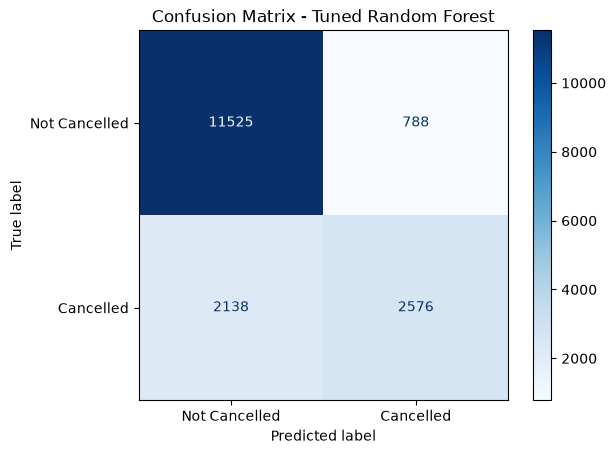

In [109]:
# Visualize confusion matrix for the selected Tuned Random Forest

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_test_predictions,
    display_labels=['Not Cancelled', 'Cancelled'],
    cmap='Blues'
)

plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

#### Interpretation of the Final Model Confusion Matrix

The confusion matrix provides a detailed view of the Tuned Random Forest model's classification performance on the test dataset.

- **11,525 True Negatives:** Non-cancelled bookings correctly predicted as not cancelled.
- **788 False Positives:** Non-cancelled bookings incorrectly predicted as cancelled.
- **2,138 False Negatives:** Cancelled bookings incorrectly predicted as not cancelled.
- **2,576 True Positives:** Cancelled bookings correctly predicted as cancelled.

The model correctly classifies a large proportion of non-cancelled bookings and produces relatively few false cancellation predictions. However, the number of false negatives shows that some actual cancellations are still missed.

This is consistent with the model's precision of **0.7658** and recall of **0.5465**. The higher precision indicates that when the model predicts a cancellation, the prediction is relatively reliable, while the lower recall indicates that the model does not detect every actual cancellation at the default classification threshold.

Therefore, the model should be treated as a decision-support tool rather than a replacement for operational judgement.

### 8.6 Interpretation of Model Behaviour

The experimental results show that the four classification algorithms performed differently because they learn relationships in different ways.

**Logistic Regression** achieved a mean cross-validation ROC-AUC of **0.8328**. As a linear classification model, it provides a useful baseline but may not capture all complex non-linear relationships and interactions among hotel booking characteristics.

**Decision Tree** achieved the lowest baseline mean cross-validation ROC-AUC of **0.7303**. A single unrestricted decision tree can create a highly complex structure that fits training observations closely, which may reduce its ability to generalize to unseen observations.

**Random Forest** improved substantially over the single Decision Tree, achieving a baseline mean cross-validation ROC-AUC of **0.8849**. Random Forest combines predictions from many decision trees, which can reduce the instability associated with relying on a single tree while capturing non-linear relationships and feature interactions.

**Gradient Boosting** also performed strongly, with a baseline mean cross-validation ROC-AUC of **0.8705**. Unlike Random Forest, Gradient Boosting builds trees sequentially, where later trees attempt to improve errors made by earlier trees.

Hyperparameter optimization improved both selected ensemble models. Random Forest improved from **0.8849** to **0.8883**, while Gradient Boosting improved from **0.8705** to **0.8870** in cross-validation ROC-AUC.

The final test results also demonstrated a performance trade-off. The Tuned Random Forest achieved higher accuracy, precision, and ROC-AUC, while the Tuned Gradient Boosting model achieved higher recall and F1-score.

These results demonstrate why multiple algorithms and multiple evaluation metrics were considered rather than relying on a single model or accuracy alone.

## 9. Technical Decisions and Evaluation 2 Summary

The model-development and optimization process followed a structured experimental approach.

The main technical decisions made during this stage were:

- Four classification algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.
- Stratified 5-fold cross-validation was used to preserve the class distribution across validation folds.
- ROC-AUC was selected as the primary cross-validation metric, while accuracy, precision, recall, F1-score, and confusion matrices were also considered during final evaluation.
- Random Forest and Gradient Boosting were selected for optimization based on their stronger baseline cross-validation results.
- Randomized Search was used for hyperparameter optimization to provide a practical balance between parameter exploration and computational cost.
- Hyperparameter tuning was performed only on the training data. The test dataset was kept separate from model development and optimization.
- Both optimized models were evaluated on the same untouched test dataset using multiple classification metrics.
- The Tuned Random Forest was selected as the final model based on the predefined evaluation strategy and its overall performance, while the higher recall and F1-score of Gradient Boosting were also acknowledged.
- The final model is intended to support hotel booking management decisions rather than automatically make operational decisions.

Overall, the modelling process demonstrates systematic algorithm comparison, appropriate validation, hyperparameter optimization, interpretation of model behaviour, and evidence-based final model selection.

In [111]:
print("Final Random Forest model:")
print(type(best_random_forest))

print("\nPreprocessor:")
print(type(preprocessor))

Final Random Forest model:


NameError: name 'best_random_forest' is not defined

In [112]:
print("Random Forest search object:")
print(type(rf_random_search))

print("\nBest Random Forest model:")
print(type(rf_random_search.best_estimator_))

print("\nPreprocessor:")
print(type(preprocessor))

Random Forest search object:
<class 'sklearn.model_selection._search.RandomizedSearchCV'>

Best Random Forest model:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

Preprocessor:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [113]:
import joblib

final_random_forest = rf_random_search.best_estimator_

joblib.dump(final_random_forest, 'final_random_forest.pkl')

print("Final Random Forest model saved successfully.")

Final Random Forest model saved successfully.


In [114]:
joblib.dump(preprocessor, 'preprocessor.pkl')

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [115]:
import os

print("Model file exists:", os.path.exists('final_random_forest.pkl'))
print("Preprocessor file exists:", os.path.exists('preprocessor.pkl'))

Model file exists: True
Preprocessor file exists: True


In [116]:
print("Current folder:", os.getcwd())
print("\nFiles in current folder:")
print(os.listdir())

Current folder: C:\Users\DELL\Hotel_Cancellation_Project

Files in current folder:
['.ipynb_checkpoints', 'final_random_forest.pkl', 'hotel_bookings.csv', 'Hotel_Booking_Cancellation_Evaluation1.ipynb', 'preprocessor.pkl']
